# 이산최적화 Term Project Code

### 필요한 파일
- acn_office001.csv (Small Dataset)
- acn_caltech.csv

## Experimental Setup

### office001
#### 데이터 전처리
- 이상치 제거
- 결측치 처리
- 타임슬롯 이산화

In [1]:
import pandas as pd
import numpy as np

# ── 1. 데이터 로드 ────────────────────────────────────────
df = pd.read_csv('data/acn_office001.csv')

df['connection_time']    = pd.to_datetime(df['connection_time'],    utc=True)
df['disconnect_time']    = pd.to_datetime(df['disconnect_time'],    utc=True)
df['done_charging_time'] = pd.to_datetime(df['done_charging_time'], utc=True)

for col in ['connection_time', 'disconnect_time', 'done_charging_time']:
    df[col] = df[col].dt.tz_convert('America/Los_Angeles')

print(f"원본 세션 수: {len(df):,}개")

# ── 2. 파생 컬럼 생성 ─────────────────────────────────────
df['duration_hr'] = (
    df['disconnect_time'] - df['connection_time']
).dt.total_seconds() / 3600

df['date'] = df['connection_time'].dt.date  # 날짜별 분리용

# ── 3. 이상치 제거 ────────────────────────────────────────
n = len(df)

# 3-1. 체류 시간 15분 미만 제거 (충전 불가)
df = df[df['duration_hr'] >= 0.25]
print(f"체류 15분 미만 제거: {n - len(df):,}개 → 남은 세션: {len(df):,}개")
n = len(df)

# 3-2. 체류 시간 24시간 초과 제거 (며칠 주차 이상치)
df = df[df['duration_hr'] <= 24]
print(f"체류 24시간 초과 제거: {n - len(df):,}개 → 남은 세션: {len(df):,}개")
n = len(df)

# 3-3. kwh_delivered 0 이하 제거
df = df[df['kwh_delivered'] > 0]
print(f"충전량 0 이하 제거: {n - len(df):,}개 → 남은 세션: {len(df):,}개")
n = len(df)

# 3-4. disconnect_time < connection_time 제거
df = df[df['disconnect_time'] > df['connection_time']]
print(f"시간 역전 세션 제거: {n - len(df):,}개 → 남은 세션: {len(df):,}개")

# ── 4. 결측치 처리 ────────────────────────────────────────
print(f"\n결측치 현황:\n{df.isnull().sum()}")

# max_rate_kw 결측 → 7.2kW 고정
df['max_rate_kw'] = df['max_rate_kw'].fillna(7.2)

# done_charging_time 결측 → disconnect_time으로 대체
df['done_charging_time'] = df['done_charging_time'].fillna(df['disconnect_time'])

# ── 5. 타임슬롯 이산화 (15분 단위) ───────────────────────
SLOT_MIN  = 15                    # 슬롯 크기 (분)
DELTA_T   = SLOT_MIN / 60         # 시간 단위 (0.25h)
DAY_START = 0                     # 하루 시작 슬롯 (00:00)
DAY_SLOTS = int(24 * 60 / SLOT_MIN)  # 하루 슬롯 수 (96)

def to_slot(dt):
    """datetime → 하루 기준 슬롯 번호 (0~95)"""
    return int((dt.hour * 60 + dt.minute) / SLOT_MIN)

df['slot_arrival']   = df['connection_time'].apply(to_slot)
df['slot_departure'] = df['disconnect_time'].apply(to_slot)

# 출발 슬롯이 도착 슬롯보다 작으면 다음날 출발 (자정 넘김)
df['slot_departure'] = df.apply(
    lambda r: r['slot_departure'] + DAY_SLOTS
    if r['slot_departure'] <= r['slot_arrival'] else r['slot_departure'],
    axis=1
)

# ── 6. 최종 컬럼 정리 ─────────────────────────────────────
df = df[[
    'session_id', 'station_id', 'date',
    'connection_time', 'disconnect_time',
    'slot_arrival', 'slot_departure',
    'kwh_delivered', 'max_rate_kw', 'duration_hr'
]].reset_index(drop=True)

# ── 7. 저장 ───────────────────────────────────────────────
df.to_csv('data/acn_office001_clean.csv', index=False)
print(f"\n✅ 전처리 완료! {len(df):,}개 세션 저장 → data/acn_office001_clean.csv")

# ── 8. 날짜별 세션 수 확인 ────────────────────────────────
daily = df.groupby('date').size().reset_index(name='session_count')
print(f"\n날짜별 세션 수 요약:")
print(daily.describe().round(1))
print(f"\n세션 수 상위 5일:\n{daily.nlargest(5, 'session_count')}")
print(f"세션 수 하위 5일:\n{daily.nsmallest(5, 'session_count')}")

원본 세션 수: 1,683개
체류 15분 미만 제거: 3개 → 남은 세션: 1,680개
체류 24시간 초과 제거: 20개 → 남은 세션: 1,660개
충전량 0 이하 제거: 0개 → 남은 세션: 1,660개
시간 역전 세션 제거: 0개 → 남은 세션: 1,660개

결측치 현황:
session_id             0
station_id             0
connection_time        0
disconnect_time        0
done_charging_time    54
kwh_delivered          0
max_rate_kw            0
duration_hr            0
charging_hr           54
avg_rate_kw           54
date                   0
dtype: int64

✅ 전처리 완료! 1,660개 세션 저장 → data/acn_office001_clean.csv

날짜별 세션 수 요약:
       session_count
count          544.0
mean             3.1
std              2.3
min              1.0
25%              1.0
50%              2.0
75%              4.0
max             14.0

세션 수 상위 5일:
           date  session_count
178  2019-12-09             14
195  2020-01-06             12
144  2019-10-18             11
182  2019-12-13             11
97   2019-08-13             10
세션 수 하위 5일:
          date  session_count
1   2019-03-26              1
5   2019-04-02            

### Caltech

#### 데이터 전처리
- office001과 동일

In [33]:
import pandas as pd
import numpy as np

# ── 1. 데이터 로드 ────────────────────────────────────────
df = pd.read_csv('data/acn_caltech.csv')

# parse_dates 대신 utc=True로 변환
df['connection_time']    = pd.to_datetime(df['connection_time'],    utc=True)
df['disconnect_time']    = pd.to_datetime(df['disconnect_time'],    utc=True)
df['done_charging_time'] = pd.to_datetime(df['done_charging_time'], utc=True)

# LA 타임존으로 변환
for col in ['connection_time', 'disconnect_time', 'done_charging_time']:
    df[col] = df[col].dt.tz_convert('America/Los_Angeles')

print(f"원본 세션 수: {len(df):,}개")

# ── 2. 파생 컬럼 생성 ─────────────────────────────────────
df['duration_hr'] = (
    df['disconnect_time'] - df['connection_time']
).dt.total_seconds() / 3600

df['date'] = df['connection_time'].dt.date  # 날짜별 분리용

# ── 3. 이상치 제거 ────────────────────────────────────────
n = len(df)

# 3-1. 체류 시간 15분 미만 제거 (충전 불가)
df = df[df['duration_hr'] >= 0.25]
print(f"체류 15분 미만 제거: {n - len(df):,}개 → 남은 세션: {len(df):,}개")
n = len(df)

# 3-2. 체류 시간 24시간 초과 제거 (며칠 주차 이상치)
df = df[df['duration_hr'] <= 24]
print(f"체류 24시간 초과 제거: {n - len(df):,}개 → 남은 세션: {len(df):,}개")
n = len(df)

# 3-3. kwh_delivered 0 이하 제거
df = df[df['kwh_delivered'] > 0]
print(f"충전량 0 이하 제거: {n - len(df):,}개 → 남은 세션: {len(df):,}개")
n = len(df)

# 3-4. disconnect_time < connection_time 제거
df = df[df['disconnect_time'] > df['connection_time']]
print(f"시간 역전 세션 제거: {n - len(df):,}개 → 남은 세션: {len(df):,}개")

# ── 4. 결측치 처리 ────────────────────────────────────────
print(f"\n결측치 현황:\n{df.isnull().sum()}")

# max_rate_kw 결측 → 7.2kW 고정
df['max_rate_kw'] = df['max_rate_kw'].fillna(7.2)

# done_charging_time 결측 → disconnect_time으로 대체
df['done_charging_time'] = df['done_charging_time'].fillna(df['disconnect_time'])

# ── 5. 타임슬롯 이산화 (15분 단위) ───────────────────────
SLOT_MIN  = 15                    # 슬롯 크기 (분)
DELTA_T   = SLOT_MIN / 60         # 시간 단위 (0.25h)
DAY_START = 0                     # 하루 시작 슬롯 (00:00)
DAY_SLOTS = int(24 * 60 / SLOT_MIN)  # 하루 슬롯 수 (96)

def to_slot(dt):
    """datetime → 하루 기준 슬롯 번호 (0~95)"""
    return int((dt.hour * 60 + dt.minute) / SLOT_MIN)

df['slot_arrival']   = df['connection_time'].apply(to_slot)
df['slot_departure'] = df['disconnect_time'].apply(to_slot)

# 출발 슬롯이 도착 슬롯보다 작으면 다음날 출발 (자정 넘김)
df['slot_departure'] = df.apply(
    lambda r: r['slot_departure'] + DAY_SLOTS
    if r['slot_departure'] <= r['slot_arrival'] else r['slot_departure'],
    axis=1
)

# ── 6. 최종 컬럼 정리 ─────────────────────────────────────
df = df[[
    'session_id', 'station_id', 'date',
    'connection_time', 'disconnect_time',
    'slot_arrival', 'slot_departure',
    'kwh_delivered', 'max_rate_kw', 'duration_hr'
]].reset_index(drop=True)

# ── 7. 저장 ───────────────────────────────────────────────
df.to_csv('data/acn_caltech_clean.csv', index=False)
print(f"\n✅ 전처리 완료! {len(df):,}개 세션 저장 → data/acn_caltech_clean.csv")

# ── 8. 날짜별 세션 수 확인 ────────────────────────────────
daily = df.groupby('date').size().reset_index(name='session_count')
print(f"\n날짜별 세션 수 요약:")
print(daily.describe().round(1))
print(f"\n세션 수 상위 5일:\n{daily.nlargest(5, 'session_count')}")
print(f"세션 수 하위 5일:\n{daily.nsmallest(5, 'session_count')}")

원본 세션 수: 31,399개
체류 15분 미만 제거: 419개 → 남은 세션: 30,980개
체류 24시간 초과 제거: 259개 → 남은 세션: 30,721개
충전량 0 이하 제거: 0개 → 남은 세션: 30,721개
시간 역전 세션 제거: 0개 → 남은 세션: 30,721개

결측치 현황:
session_id               0
station_id               0
connection_time          0
disconnect_time          0
done_charging_time    1973
kwh_delivered            0
max_rate_kw              0
duration_hr              0
date                     0
dtype: int64

✅ 전처리 완료! 30,721개 세션 저장 → data/acn_caltech_clean.csv

날짜별 세션 수 요약:
       session_count
count         1081.0
mean            28.4
std             24.4
min              1.0
25%              8.0
50%             22.0
75%             41.0
max            105.0

세션 수 상위 5일:
           date  session_count
139  2018-09-11            105
153  2018-09-25            101
160  2018-10-02            100
189  2018-10-31             99
152  2018-09-24             96
세션 수 하위 5일:
           date  session_count
582  2019-11-28              1
609  2019-12-26              1
695  2020-03-23   

In [36]:
df = pd.read_csv('data/acn_caltech_clean.csv')
print(df.columns.tolist())

['session_id', 'station_id', 'date', 'connection_time', 'disconnect_time', 'slot_arrival', 'slot_departure', 'kwh_delivered', 'max_rate_kw', 'duration_hr']


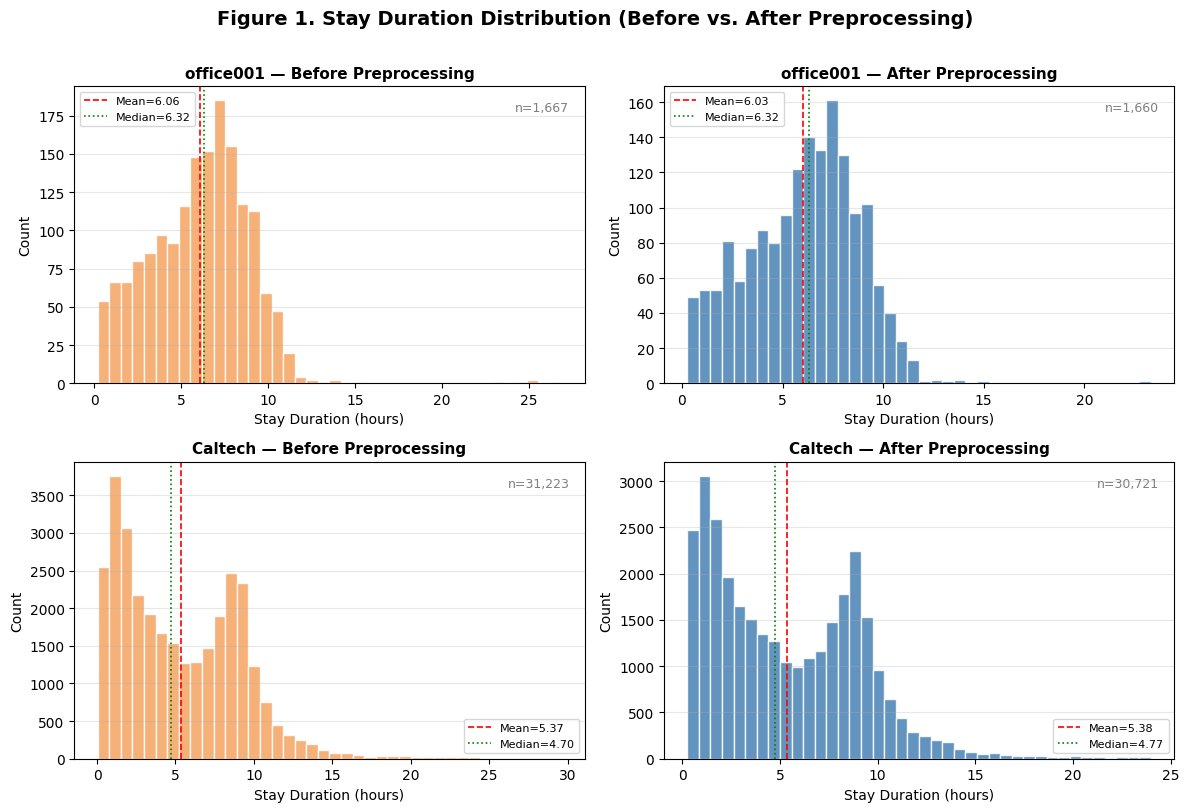

✅ Saved: figures/dist_duration.png


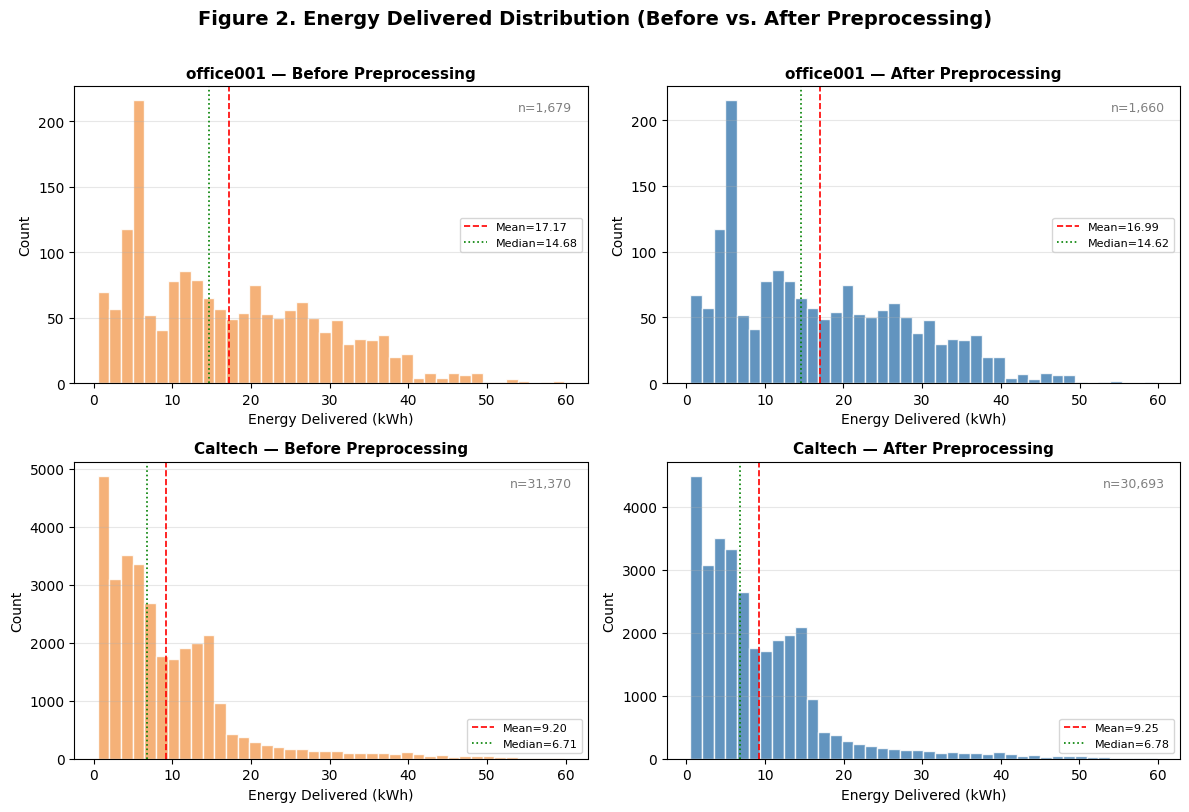

✅ Saved: figures/dist_kwh.png


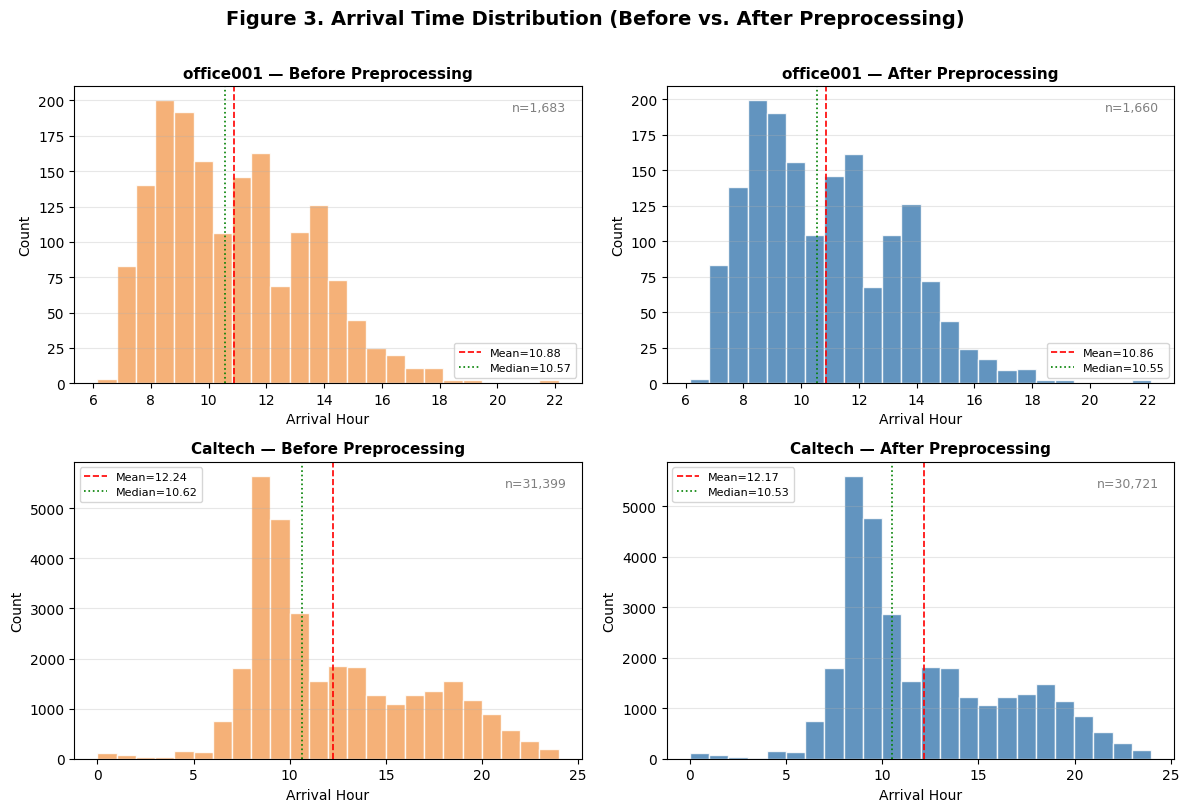

✅ Saved: figures/dist_arrival.png


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import os

os.makedirs('figures', exist_ok=True)

# ── 데이터 로드 ────────────────────────────────────────────
# 전처리 전
df_office_raw = pd.read_csv('data/acn_office001.csv')
df_caltech_raw = pd.read_csv('data/acn_caltech.csv')

# 전처리 후
df_office_clean = pd.read_csv('data/acn_office001_clean.csv')
df_caltech_clean = pd.read_csv('data/acn_caltech_clean.csv')

# 시간 변환
for df in [df_office_raw, df_caltech_raw]:
    df['connection_time'] = pd.to_datetime(df['connection_time'], utc=True).dt.tz_convert('America/Los_Angeles')
    df['disconnect_time']  = pd.to_datetime(df['disconnect_time'], utc=True).dt.tz_convert('America/Los_Angeles')
    df['duration_hr'] = (df['disconnect_time'] - df['connection_time']).dt.total_seconds() / 3600
    df['arrival_hour'] = df['connection_time'].dt.hour + df['connection_time'].dt.minute / 60

for df in [df_office_clean, df_caltech_clean]:
    df['connection_time'] = pd.to_datetime(df['connection_time'], utc=True).dt.tz_convert('America/Los_Angeles')
    df['arrival_hour'] = df['connection_time'].dt.hour + df['connection_time'].dt.minute / 60

# ── 공통 플롯 함수 ─────────────────────────────────────────
def plot_2x2(col, xlabel, bins, title, filename, xlim=None):
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    fig.suptitle(title, fontsize=14, fontweight='bold', y=1.01)

    datasets = [
        (df_office_raw,   axes[0, 0], 'office001 — Before Preprocessing', '#F4A460'),
        (df_office_clean, axes[0, 1], 'office001 — After Preprocessing',  '#4682B4'),
        (df_caltech_raw,  axes[1, 0], 'Caltech — Before Preprocessing',   '#F4A460'),
        (df_caltech_clean,axes[1, 1], 'Caltech — After Preprocessing',    '#4682B4'),
    ]

    for df, ax, subtitle, color in datasets:
        data = df[col].dropna()
        if xlim:
            data = data[data <= xlim]
        ax.hist(data, bins=bins, color=color, edgecolor='white', alpha=0.85)
        ax.set_title(subtitle, fontsize=11, fontweight='bold')
        ax.set_xlabel(xlabel, fontsize=10)
        ax.set_ylabel('Count', fontsize=10)
        ax.grid(alpha=0.3, axis='y')
        # 통계 정보 표시
        ax.axvline(data.mean(), color='red', linestyle='--', linewidth=1.2,
                   label=f'Mean={data.mean():.2f}')
        ax.axvline(data.median(), color='green', linestyle=':', linewidth=1.2,
                   label=f'Median={data.median():.2f}')
        ax.legend(fontsize=8)
        ax.text(0.97, 0.95, f'n={len(data):,}',
                transform=ax.transAxes, ha='right', va='top',
                fontsize=9, color='gray')

    plt.tight_layout()
    plt.savefig(f'figures/{filename}', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✅ Saved: figures/{filename}")

# ── Figure 1: Duration Distribution ───────────────────────
plot_2x2(
    col      = 'duration_hr',
    xlabel   = 'Stay Duration (hours)',
    bins     = 40,
    title    = 'Figure 1. Stay Duration Distribution (Before vs. After Preprocessing)',
    filename = 'dist_duration.png',
    xlim     = 30
)

# ── Figure 2: kWh Delivered Distribution ──────────────────
plot_2x2(
    col      = 'kwh_delivered',
    xlabel   = 'Energy Delivered (kWh)',
    bins     = 40,
    title    = 'Figure 2. Energy Delivered Distribution (Before vs. After Preprocessing)',
    filename = 'dist_kwh.png',
    xlim     = 60
)

# ── Figure 3: Arrival Hour Distribution ───────────────────
plot_2x2(
    col      = 'arrival_hour',
    xlabel   = 'Arrival Hour',
    bins     = 24,
    title    = 'Figure 3. Arrival Time Distribution (Before vs. After Preprocessing)',
    filename = 'dist_arrival.png',
    xlim     = None
)

#### Data Summary & Instance Generation
- 전처리된 데이터의 Sessions, Average Vehicles/Dat, C 변압기 용량 확인
- Instance 생성

#### office001

In [4]:
from acnportal.acnsim.network import sites
import numpy as np

network = sites.office001_acn()
magnitudes = network.magnitudes
voltage = 208.0

print("=== office001 제약별 용량 ===")
constraint_names = [f"constraint_{i}" for i in range(len(magnitudes))]
for name, mag in zip(constraint_names, magnitudes):
    kw = np.sqrt(3) * voltage * mag / 1000
    print(f"  {name}: {mag:.1f} A → {kw:.1f} kW")

c:\Users\geo48\anaconda3\envs\DO\Lib\site-packages\acnportal\acnsim\base.py:17: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


=== office001 제약별 용량 ===
  constraint_0: 138.9 A → 50.0 kW
  constraint_1: 138.9 A → 50.0 kW
  constraint_2: 138.9 A → 50.0 kW
  constraint_3: 60.2 A → 21.7 kW
  constraint_4: 60.2 A → 21.7 kW
  constraint_5: 60.2 A → 21.7 kW


변압기 용량(C)이 50.0 kW임을 확인

In [5]:
import pandas as pd
import numpy as np
from datetime import date

# ── 0. 설정 ───────────────────────────────────────────────
DELTA_T   = 0.25       # 타임슬롯 크기 (15분 = 0.25h)
DAY_SLOTS = 96         # 하루 슬롯 수 (24h / 0.25h)
C         = 50.0      # 변압기 용량 (kW)

# ── 1. 데이터 로드 ────────────────────────────────────────
df = pd.read_csv(
    'data/acn_office001_clean.csv',
    parse_dates=['connection_time', 'disconnect_time']
)
df['date'] = pd.to_datetime(df['date']).dt.date
print(f"전체 세션 수: {len(df):,}개")
print(f"날짜 범위: {df['date'].min()} ~ {df['date'].max()}")

# ── 2. 날짜별 인스턴스 생성 함수 ─────────────────────────
def make_instance(df, target_date):
    """
    특정 날짜의 세션으로 MIP 인스턴스 생성
    
    Returns:
        instance (dict): MIP에 바로 넣을 수 있는 파라미터 딕셔너리
    """
    day_df = df[df['date'] == target_date].copy().reset_index(drop=True)
    
    if len(day_df) == 0:
        print(f"⚠️ {target_date} 세션 없음")
        return None

    # 차량 집합
    vehicles = day_df['session_id'].tolist()
    I = list(range(len(vehicles)))           # 차량 인덱스
    T = list(range(DAY_SLOTS))               # 타임슬롯 인덱스 (0~95)

    # 파라미터 추출
    a = day_df['slot_arrival'].tolist()      # 도착 슬롯
    d = day_df['slot_departure'].tolist()    # 출발 슬롯
    e = day_df['kwh_delivered'].tolist()     # 필요 충전량 (kWh)
    r_max = day_df['max_rate_kw'].tolist()   # 최대 충전율 (kW)

    # 슬롯 범위 보정 (0~95 초과 방지)
    d = [min(di, DAY_SLOTS - 1) for di in d]
    a = [max(ai, 0) for ai in a]

    # 실현 가능성 체크
    # 각 차량이 이론적으로 충전 가능한지 확인
    infeasible = []
    for i in I:
        max_possible = r_max[i] * (d[i] - a[i] + 1) * DELTA_T
        if max_possible < e[i]:
            infeasible.append(i)

    if infeasible:
        print(f"  ⚠️ 충전 불가 차량 {len(infeasible)}대 제거 (체류 시간 부족)")
        mask = [i for i in I if i not in infeasible]
        I      = list(range(len(mask)))
        a      = [a[i] for i in mask]
        d      = [d[i] for i in mask]
        e      = [e[i] for i in mask]
        r_max  = [r_max[i] for i in mask]
        vehicles = [vehicles[i] for i in mask]

    instance = {
        'date'     : target_date,
        'I'        : I,             # 차량 인덱스 리스트
        'T'        : T,             # 타임슬롯 리스트
        'n_vehicles': len(I),       # 차량 수
        'n_slots'  : DAY_SLOTS,     # 슬롯 수
        'a'        : a,             # 도착 슬롯
        'd'        : d,             # 출발 슬롯
        'e'        : e,             # 필요 충전량 (kWh)
        'r_max'    : r_max,         # 최대 충전율 (kW)
        'delta_t'  : DELTA_T,       # 슬롯 크기 (h)
        'C'        : C,             # 변압기 용량 (kW)
        'vehicles' : vehicles,      # session_id 리스트
    }

    return instance


# ── 3. 인스턴스 요약 출력 함수 ────────────────────────────
def print_instance_summary(instance):
    if instance is None:
        return
    I, a, d, e, r_max = (
        instance['I'], instance['a'], instance['d'],
        instance['e'], instance['r_max']
    )
    print(f"\n{'='*45}")
    print(f"날짜       : {instance['date']}")
    print(f"차량 수     : {instance['n_vehicles']}대")
    print(f"타임슬롯 수  : {instance['n_slots']}개 (15분 단위)")
    print(f"변압기 용량  : {instance['C']} kW")
    print(f"결정변수 수  : {instance['n_vehicles'] * instance['n_slots']:,}개")
    print(f"---")
    print(f"체류 시간   : 평균 {np.mean([d[i]-a[i] for i in I])*0.25:.1f}h  "
          f"최대 {max([d[i]-a[i] for i in I])*0.25:.1f}h")
    print(f"필요 충전량  : 평균 {np.mean(e):.1f} kWh  최대 {max(e):.1f} kWh")
    print(f"최대 충전율  : {set(r_max)} kW")
    print(f"{'='*45}")


# ── 4. 실행 예시 ──────────────────────────────────────────
# 특정 날짜 하나
target = date(2019, 5, 1)
instance = make_instance(df, target)
print_instance_summary(instance)

# 여러 날짜 한번에 생성
dates_to_run = sorted(df['date'].unique())[:5]  # 처음 5일
instances = {}
for d_target in dates_to_run:
    inst = make_instance(df, d_target)
    if inst is not None:
        instances[d_target] = inst

print(f"\n✅ 인스턴스 생성 완료: {len(instances)}개")

전체 세션 수: 1,660개
날짜 범위: 2019-03-25 ~ 2021-09-13

날짜       : 2019-05-01
차량 수     : 3대
타임슬롯 수  : 96개 (15분 단위)
변압기 용량  : 50.0 kW
결정변수 수  : 288개
---
체류 시간   : 평균 7.4h  최대 7.5h
필요 충전량  : 평균 12.2 kWh  최대 18.6 kWh
최대 충전율  : {7.2} kW

✅ 인스턴스 생성 완료: 5개


#### Caltech

In [6]:
from acnportal.acnsim.network import sites
import numpy as np

network = sites.caltech_acn()

# 제약 조건 DataFrame으로 확인
print("=== 제약 조건 ===")
print(network.constraints_as_df())

# 전압 확인
print("\n=== 전압 (V) ===")
print(np.unique(network.voltages))

# max pilot signal 확인
print("\n=== max_pilot_signals ===")
print(np.unique(network.max_pilot_signals))

# magnitudes로 용량 확인
print("\n=== magnitudes ===")
print(network.magnitudes)

=== 제약 조건 ===
             CA-308  CA-508  CA-303  CA-513  CA-310  CA-506  CA-316  CA-500  \
CC Pod         0.00    0.00    0.00    0.00    0.00    0.00    0.00    0.00   
AV Pod         0.00    0.00    0.00    0.00    0.00    0.00    0.00    0.00   
Secondary A    1.00    1.00    1.00    1.00    1.00    1.00    1.00    1.00   
Secondary B   -1.00   -1.00   -1.00   -1.00   -1.00   -1.00   -1.00   -1.00   
Secondary C    0.00    0.00    0.00    0.00    0.00    0.00    0.00    0.00   
Primary A      0.25    0.25    0.25    0.25    0.25    0.25    0.25    0.25   
Primary B     -0.50   -0.50   -0.50   -0.50   -0.50   -0.50   -0.50   -0.50   
Primary C      0.25    0.25    0.25    0.25    0.25    0.25    0.25    0.25   

             CA-318  CA-498  ...  CA-306  CA-510  CA-315  CA-501  CA-319  \
CC Pod         0.00    0.00  ...    0.00    0.00    0.00    0.00    0.00   
AV Pod         0.00    0.00  ...    0.00    0.00    0.00    0.00    0.00   
Secondary A    1.00    1.00  ...   -1.00   -1.

In [7]:
from acnportal.acnsim.network import sites
import numpy as np

network = sites.caltech_acn()

magnitudes = network.magnitudes
voltage = np.unique(network.voltages)[0]

print(f"전압: {voltage} V")
print(f"\n=== 제약별 용량 ===")

constraint_names = ['CC Pod', 'AV Pod', 
                    'Secondary A', 'Secondary B', 'Secondary C',
                    'Primary A', 'Primary B', 'Primary C']

voltage = 208.0  # 모든 스테이션 동일

for name, mag in zip(constraint_names, magnitudes):
    kw = mag * voltage / 1000
    print(f"  {name:15s}: {mag:.1f} A → {kw:.1f} kW")

전압: {'CA-308': np.float64(208.0), 'CA-508': np.float64(208.0), 'CA-303': np.float64(208.0), 'CA-513': np.float64(208.0), 'CA-310': np.float64(208.0), 'CA-506': np.float64(208.0), 'CA-316': np.float64(208.0), 'CA-500': np.float64(208.0), 'CA-318': np.float64(208.0), 'CA-498': np.float64(208.0), 'CA-324': np.float64(208.0), 'CA-325': np.float64(208.0), 'CA-326': np.float64(208.0), 'CA-327': np.float64(208.0), 'CA-489': np.float64(208.0), 'CA-490': np.float64(208.0), 'CA-491': np.float64(208.0), 'CA-492': np.float64(208.0), 'CA-322': np.float64(208.0), 'CA-493': np.float64(208.0), 'CA-496': np.float64(208.0), 'CA-320': np.float64(208.0), 'CA-495': np.float64(208.0), 'CA-321': np.float64(208.0), 'CA-323': np.float64(208.0), 'CA-494': np.float64(208.0), 'CA-304': np.float64(208.0), 'CA-512': np.float64(208.0), 'CA-305': np.float64(208.0), 'CA-511': np.float64(208.0), 'CA-313': np.float64(208.0), 'CA-503': np.float64(208.0), 'CA-311': np.float64(208.0), 'CA-505': np.float64(208.0), 'CA-317':

In [8]:
import numpy as np

voltage = 208.0  # V (선간전압)

constraint_names = ['CC Pod', 'AV Pod',
                    'Secondary A', 'Secondary B', 'Secondary C',
                    'Primary A', 'Primary B', 'Primary C']

print("=== 제약별 용량 (3상 보정) ===")
for name, mag in zip(constraint_names, magnitudes):
    kw = np.sqrt(3) * voltage * mag / 1000
    print(f"  {name:15s}: {mag:.1f} A → {kw:.1f} kW")

=== 제약별 용량 (3상 보정) ===
  CC Pod         : 80.0 A → 28.8 kW
  AV Pod         : 80.0 A → 28.8 kW
  Secondary A    : 416.7 A → 150.1 kW
  Secondary B    : 416.7 A → 150.1 kW
  Secondary C    : 416.7 A → 150.1 kW
  Primary A      : 180.5 A → 65.0 kW
  Primary B      : 180.5 A → 65.0 kW
  Primary C      : 180.5 A → 65.0 kW


변압기 용량(C)이 150.0 kW임을 확인

In [9]:
import pandas as pd
import numpy as np
from datetime import date

# ── 0. 설정 ───────────────────────────────────────────────
DELTA_T   = 0.25       # 타임슬롯 크기 (15분 = 0.25h)
DAY_SLOTS = 96         # 하루 슬롯 수 (24h / 0.25h)
C         = 150.0      # 변압기 용량 (kW)

# ── 1. 데이터 로드 ────────────────────────────────────────
df = pd.read_csv(
    'data/acn_caltech_clean.csv',
    parse_dates=['connection_time', 'disconnect_time']
)
df['date'] = pd.to_datetime(df['date']).dt.date
print(f"전체 세션 수: {len(df):,}개")
print(f"날짜 범위: {df['date'].min()} ~ {df['date'].max()}")

# ── 2. 날짜별 인스턴스 생성 함수 ─────────────────────────
def make_instance(df, target_date):
    """
    특정 날짜의 세션으로 MIP 인스턴스 생성
    
    Returns:
        instance (dict): MIP에 바로 넣을 수 있는 파라미터 딕셔너리
    """
    day_df = df[df['date'] == target_date].copy().reset_index(drop=True)
    
    if len(day_df) == 0:
        print(f"⚠️ {target_date} 세션 없음")
        return None

    # 차량 집합
    vehicles = day_df['session_id'].tolist()
    I = list(range(len(vehicles)))           # 차량 인덱스
    T = list(range(DAY_SLOTS))               # 타임슬롯 인덱스 (0~95)

    # 파라미터 추출
    a = day_df['slot_arrival'].tolist()      # 도착 슬롯
    d = day_df['slot_departure'].tolist()    # 출발 슬롯
    e = day_df['kwh_delivered'].tolist()     # 필요 충전량 (kWh)
    r_max = day_df['max_rate_kw'].tolist()   # 최대 충전율 (kW)

    # 슬롯 범위 보정 (0~95 초과 방지)
    d = [min(di, DAY_SLOTS - 1) for di in d]
    a = [max(ai, 0) for ai in a]

    # 실현 가능성 체크
    # 각 차량이 이론적으로 충전 가능한지 확인
    infeasible = []
    for i in I:
        max_possible = r_max[i] * (d[i] - a[i] + 1) * DELTA_T
        if max_possible < e[i]:
            infeasible.append(i)

    if infeasible:
        print(f"  ⚠️ 충전 불가 차량 {len(infeasible)}대 제거 (체류 시간 부족)")
        mask = [i for i in I if i not in infeasible]
        I      = list(range(len(mask)))
        a      = [a[i] for i in mask]
        d      = [d[i] for i in mask]
        e      = [e[i] for i in mask]
        r_max  = [r_max[i] for i in mask]
        vehicles = [vehicles[i] for i in mask]

    instance = {
        'date'     : target_date,
        'I'        : I,             # 차량 인덱스 리스트
        'T'        : T,             # 타임슬롯 리스트
        'n_vehicles': len(I),       # 차량 수
        'n_slots'  : DAY_SLOTS,     # 슬롯 수
        'a'        : a,             # 도착 슬롯
        'd'        : d,             # 출발 슬롯
        'e'        : e,             # 필요 충전량 (kWh)
        'r_max'    : r_max,         # 최대 충전율 (kW)
        'delta_t'  : DELTA_T,       # 슬롯 크기 (h)
        'C'        : C,             # 변압기 용량 (kW)
        'vehicles' : vehicles,      # session_id 리스트
    }

    return instance


# ── 3. 인스턴스 요약 출력 함수 ────────────────────────────
def print_instance_summary(instance):
    if instance is None:
        return
    I, a, d, e, r_max = (
        instance['I'], instance['a'], instance['d'],
        instance['e'], instance['r_max']
    )
    print(f"\n{'='*45}")
    print(f"날짜       : {instance['date']}")
    print(f"차량 수     : {instance['n_vehicles']}대")
    print(f"타임슬롯 수  : {instance['n_slots']}개 (15분 단위)")
    print(f"변압기 용량  : {instance['C']} kW")
    print(f"결정변수 수  : {instance['n_vehicles'] * instance['n_slots']:,}개")
    print(f"---")
    print(f"체류 시간   : 평균 {np.mean([d[i]-a[i] for i in I])*0.25:.1f}h  "
          f"최대 {max([d[i]-a[i] for i in I])*0.25:.1f}h")
    print(f"필요 충전량  : 평균 {np.mean(e):.1f} kWh  최대 {max(e):.1f} kWh")
    print(f"최대 충전율  : {set(r_max)} kW")
    print(f"{'='*45}")


# ── 4. 실행 예시 ──────────────────────────────────────────
# 특정 날짜 하나
target = date(2019, 5, 1)
instance = make_instance(df, target)
print_instance_summary(instance)

# 여러 날짜 한번에 생성
dates_to_run = sorted(df['date'].unique())[:5]  # 처음 5일
instances = {}
for d_target in dates_to_run:
    inst = make_instance(df, d_target)
    if inst is not None:
        instances[d_target] = inst

print(f"\n✅ 인스턴스 생성 완료: {len(instances)}개")

전체 세션 수: 30,721개
날짜 범위: 2018-04-25 ~ 2021-09-13

날짜       : 2019-05-01
차량 수     : 38대
타임슬롯 수  : 96개 (15분 단위)
변압기 용량  : 150.0 kW
결정변수 수  : 3,648개
---
체류 시간   : 평균 7.2h  최대 14.5h
필요 충전량  : 평균 11.2 kWh  최대 51.9 kWh
최대 충전율  : {6.9, 7.93, 7.03, 8.61, 9.49, 8.73, 8.7, 9.3, 6.86, 11.99, 15.54, 11.63, 11.72, 11.54, 19.0, 20.26, 16.35, 22.0, 18.0, 11.71, 11.34, 7.05} kW
  ⚠️ 충전 불가 차량 1대 제거 (체류 시간 부족)
  ⚠️ 충전 불가 차량 3대 제거 (체류 시간 부족)
  ⚠️ 충전 불가 차량 1대 제거 (체류 시간 부족)

✅ 인스턴스 생성 완료: 5개


#### 필요한 함수 정의
- instance 생성 함수
- Heuristics를 위한 함수 (UC, EDF, RR)

In [29]:
def make_instance(df, target_date):
    """
    특정 날짜의 세션으로 MIP 인스턴스 생성
    
    Returns:
        instance (dict): MIP에 바로 넣을 수 있는 파라미터 딕셔너리
    """
    day_df = df[df['date'] == target_date].copy().reset_index(drop=True)
    
    if len(day_df) == 0:
        print(f"⚠️ {target_date} 세션 없음")
        return None

    # 차량 집합
    vehicles = day_df['session_id'].tolist()
    I = list(range(len(vehicles)))           # 차량 인덱스
    T = list(range(DAY_SLOTS))               # 타임슬롯 인덱스 (0~95)

    # 파라미터 추출
    a = day_df['slot_arrival'].tolist()      # 도착 슬롯
    d = day_df['slot_departure'].tolist()    # 출발 슬롯
    e = day_df['kwh_delivered'].tolist()     # 필요 충전량 (kWh)
    r_max = day_df['max_rate_kw'].tolist()   # 최대 충전율 (kW)

    # 슬롯 범위 보정 (0~95 초과 방지)
    d = [min(di, DAY_SLOTS - 1) for di in d]
    a = [max(ai, 0) for ai in a]

    # 실현 가능성 체크
    # 각 차량이 이론적으로 충전 가능한지 확인
    infeasible = []
    for i in I:
        max_possible = r_max[i] * (d[i] - a[i] + 1) * DELTA_T
        if max_possible < e[i]:
            infeasible.append(i)

    if infeasible:
        print(f"  ⚠️ 충전 불가 차량 {len(infeasible)}대 제거 (체류 시간 부족)")
        mask = [i for i in I if i not in infeasible]
        I      = list(range(len(mask)))
        a      = [a[i] for i in mask]
        d      = [d[i] for i in mask]
        e      = [e[i] for i in mask]
        r_max  = [r_max[i] for i in mask]
        vehicles = [vehicles[i] for i in mask]

    instance = {
        'date'     : target_date,
        'I'        : I,             # 차량 인덱스 리스트
        'T'        : T,             # 타임슬롯 리스트
        'n_vehicles': len(I),       # 차량 수
        'n_slots'  : DAY_SLOTS,     # 슬롯 수
        'a'        : a,             # 도착 슬롯
        'd'        : d,             # 출발 슬롯
        'e'        : e,             # 필요 충전량 (kWh)
        'r_max'    : r_max,         # 최대 충전율 (kW)
        'delta_t'  : DELTA_T,       # 슬롯 크기 (h)
        'C'        : C,             # 변압기 용량 (kW)
        'vehicles' : vehicles,      # session_id 리스트
    }

    return instance

In [11]:
def run_uc(inst):
    I, T    = inst['I'], inst['T']
    a, d    = inst['a'], inst['d']
    e       = inst['e']
    r_max   = inst['r_max']
    DELTA_T = inst['delta_t']
    C       = inst['C']

    r_uc      = {(i, t): 0.0 for i in I for t in T}
    for i in I:
        remaining = e[i]
        for t in range(a[i], d[i] + 1):
            if remaining <= 0:
                break
            charge     = min(r_max[i], remaining / DELTA_T)
            r_uc[i, t] = charge
            remaining -= charge * DELTA_T

    load      = [sum(r_uc[i, t] for i in I) for t in T]
    peak      = max(load)
    satisfied = sum(
        1 for i in I
        if sum(r_uc[i, t] * DELTA_T for t in range(a[i], d[i] + 1)) >= e[i] - 0.01
    )
    return {'method': 'UC', 'r': r_uc, 'load': load, 'peak': peak, 'satisfied': satisfied}


def run_edf(inst):
    I, T    = inst['I'], inst['T']
    a, d    = inst['a'], inst['d']
    e       = inst['e']
    r_max   = inst['r_max']
    DELTA_T = inst['delta_t']
    C       = inst['C']

    r_edf     = {(i, t): 0.0 for i in I for t in T}
    remaining = {i: e[i] for i in I}

    for t in T:
        active        = [i for i in I if a[i] <= t <= d[i] and remaining[i] > 0]
        active_sorted = sorted(active, key=lambda i: d[i])
        capacity_left = C
        for i in active_sorted:
            if capacity_left <= 0:
                break
            charge         = min(r_max[i], remaining[i] / DELTA_T, capacity_left)
            r_edf[i, t]   = charge
            remaining[i] -= charge * DELTA_T
            capacity_left -= charge

    load      = [sum(r_edf[i, t] for i in I) for t in T]
    peak      = max(load)
    satisfied = sum(
        1 for i in I
        if sum(r_edf[i, t] * DELTA_T for t in range(a[i], d[i] + 1)) >= e[i] - 0.01
    )
    return {'method': 'EDF', 'r': r_edf, 'load': load, 'peak': peak, 'satisfied': satisfied}


def run_rr(inst):
    I, T    = inst['I'], inst['T']
    a, d    = inst['a'], inst['d']
    e       = inst['e']
    r_max   = inst['r_max']
    DELTA_T = inst['delta_t']
    C       = inst['C']

    r_rr      = {(i, t): 0.0 for i in I for t in T}
    remaining = {i: e[i] for i in I}

    for t in T:
        active = [i for i in I if a[i] <= t <= d[i] and remaining[i] > 0]
        if not active:
            continue
        share = C / len(active)
        for i in active:
            charge        = min(r_max[i], share, remaining[i] / DELTA_T)
            r_rr[i, t]   = charge
            remaining[i] -= charge * DELTA_T

    load      = [sum(r_rr[i, t] for i in I) for t in T]
    peak      = max(load)
    satisfied = sum(
        1 for i in I
        if sum(r_rr[i, t] * DELTA_T for t in range(a[i], d[i] + 1)) >= e[i] - 0.01
    )
    return {'method': 'RR', 'r': r_rr, 'load': load, 'peak': peak, 'satisfied': satisfied}

## 데이터 전처리 요약
- Peak Power Comparison (Table 3.2)

In [55]:
import pandas as pd

# ── office001 ─────────────────────────────────────────────
df_office_raw   = pd.read_csv('data/acn_office001.csv')
df_office_clean = pd.read_csv('data/acn_office001_clean.csv')

df_office_raw['connection_time'] = pd.to_datetime(df_office_raw['connection_time'], utc=True).dt.tz_convert('America/Los_Angeles')
df_office_raw['disconnect_time'] = pd.to_datetime(df_office_raw['disconnect_time'], utc=True).dt.tz_convert('America/Los_Angeles')
df_office_raw['duration_hr'] = (df_office_raw['disconnect_time'] - df_office_raw['connection_time']).dt.total_seconds() / 3600

print("=== office001 ===")
print(f"{'':30s} {'Before':>10} {'After':>10} {'Removed':>10}")
print("-" * 62)
print(f"{'Total sessions':30s} {len(df_office_raw):>10,} {len(df_office_clean):>10,} {len(df_office_raw)-len(df_office_clean):>10,}")
print(f"{'Duration < 15min':30s} {(df_office_raw['duration_hr'] < 0.25).sum():>10,}")
print(f"{'Duration > 24hr':30s} {(df_office_raw['duration_hr'] > 24).sum():>10,}")
print(f"{'kwh_delivered <= 0':30s} {(df_office_raw['kwh_delivered'] <= 0).sum():>10,}")
print(f"{'Missing kwh_delivered':30s} {df_office_raw['kwh_delivered'].isnull().sum():>10,}")
print(f"\n{'duration_hr mean':30s} {df_office_raw['duration_hr'].mean():>10.2f} {df_office_clean['duration_hr'].mean():>10.2f}")
print(f"{'duration_hr std':30s} {df_office_raw['duration_hr'].std():>10.2f} {df_office_clean['duration_hr'].std():>10.2f}")
print(f"{'kwh_delivered mean':30s} {df_office_raw['kwh_delivered'].mean():>10.2f} {df_office_clean['kwh_delivered'].mean():>10.2f}")
print(f"{'kwh_delivered std':30s} {df_office_raw['kwh_delivered'].std():>10.2f} {df_office_clean['kwh_delivered'].std():>10.2f}")

print()

# ── Caltech ───────────────────────────────────────────────
df_caltech_raw   = pd.read_csv('data/acn_caltech.csv')
df_caltech_clean = pd.read_csv('data/acn_caltech_clean.csv')

df_caltech_raw['connection_time'] = pd.to_datetime(df_caltech_raw['connection_time'], utc=True).dt.tz_convert('America/Los_Angeles')
df_caltech_raw['disconnect_time'] = pd.to_datetime(df_caltech_raw['disconnect_time'], utc=True).dt.tz_convert('America/Los_Angeles')
df_caltech_raw['duration_hr'] = (df_caltech_raw['disconnect_time'] - df_caltech_raw['connection_time']).dt.total_seconds() / 3600

print("=== Caltech ===")
print(f"{'':30s} {'Before':>10} {'After':>10} {'Removed':>10}")
print("-" * 62)
print(f"{'Total sessions':30s} {len(df_caltech_raw):>10,} {len(df_caltech_clean):>10,} {len(df_caltech_raw)-len(df_caltech_clean):>10,}")
print(f"{'Duration < 15min':30s} {(df_caltech_raw['duration_hr'] < 0.25).sum():>10,}")
print(f"{'Duration > 24hr':30s} {(df_caltech_raw['duration_hr'] > 24).sum():>10,}")
print(f"{'kwh_delivered <= 0':30s} {(df_caltech_raw['kwh_delivered'] <= 0).sum():>10,}")
print(f"{'Missing kwh_delivered':30s} {df_caltech_raw['kwh_delivered'].isnull().sum():>10,}")
print(f"\n{'duration_hr mean':30s} {df_caltech_raw['duration_hr'].mean():>10.2f} {df_caltech_clean['duration_hr'].mean():>10.2f}")
print(f"{'duration_hr std':30s} {df_caltech_raw['duration_hr'].std():>10.2f} {df_caltech_clean['duration_hr'].std():>10.2f}")
print(f"{'kwh_delivered mean':30s} {df_caltech_raw['kwh_delivered'].mean():>10.2f} {df_caltech_clean['kwh_delivered'].mean():>10.2f}")
print(f"{'kwh_delivered std':30s} {df_caltech_raw['kwh_delivered'].std():>10.2f} {df_caltech_clean['kwh_delivered'].std():>10.2f}")

=== office001 ===
                                   Before      After    Removed
--------------------------------------------------------------
Total sessions                      1,683      1,660         23
Duration < 15min                        3
Duration > 24hr                        20
kwh_delivered <= 0                      0
Missing kwh_delivered                   0

duration_hr mean                     6.42       6.03
duration_hr std                      4.79       2.73
kwh_delivered mean                  17.27      16.99
kwh_delivered std                   12.01      11.54

=== Caltech ===
                                   Before      After    Removed
--------------------------------------------------------------
Total sessions                     31,399     30,721        678
Duration < 15min                      419
Duration > 24hr                       259
kwh_delivered <= 0                      0
Missing kwh_delivered                   0

duration_hr mean                 

### MIP 모델링
- Gurobi 사용
$$min \ \ Z$$

#### office001

In [54]:
import gurobipy as gp
from gurobipy import GRB
from datetime import date
import time

# ── 0. 인스턴스 로드 ──────────────────────────────────────
df_office = pd.read_csv('data/acn_office001_clean.csv')
df_office['date'] = pd.to_datetime(df_office['date']).dt.date

target = date(2019, 5, 1)
inst = make_instance(df_office, target, site='office001')  # ← office001

I       = inst['I']
T       = inst['T']
a       = inst['a']
d       = inst['d']
e       = inst['e']
r_max   = inst['r_max']
C       = inst['C']
DELTA_T = inst['delta_t']

print(f"Date      : {target}")
print(f"Vehicles  : {len(I)}대")
print(f"C         : {C} kW")

# ── 1. 모델 생성 ──────────────────────────────────────────
mdl = gp.Model('EV_Charging_office001')

r = mdl.addVars(I, T, lb=0, name='r')
y = mdl.addVars(I, T, vtype=GRB.BINARY, name='y')
Z = mdl.addVar(lb=0, name='Z')

mdl.setObjective(Z, GRB.MINIMIZE)

for i in I:
    mdl.addConstr(
        gp.quicksum(r[i, t] * DELTA_T for t in range(a[i], d[i] + 1)) >= e[i],
        name=f'C1_{i}'
    )

for i in I:
    for t in T:
        mdl.addConstr(r[i, t] <= r_max[i] * y[i, t], name=f'C2_{i}_{t}')

for i in I:
    for t in T:
        if t < a[i] or t > d[i]:
            mdl.addConstr(y[i, t] == 0, name=f'C3_{i}_{t}')

for t in T:
    mdl.addConstr(gp.quicksum(r[i, t] for i in I) <= Z, name=f'C4_{t}')

for t in T:
    mdl.addConstr(gp.quicksum(r[i, t] for i in I) <= C, name=f'C5_{t}')

# ── 2. 풀기 ───────────────────────────────────────────────
mdl.update()
print(f"\n=== Model Info ===")
print(f"Variables  : {mdl.NumVars:,}")
print(f"Constraints: {mdl.NumConstrs:,}")

start = time.time()
mdl.optimize()
elapsed = time.time() - start

# ── 3. 결과 출력 ──────────────────────────────────────────
if mdl.Status == GRB.OPTIMAL:
    print(f"\n=== Solution ===")
    print(f"Status    : OPTIMAL")
    print(f"Peak Z*   : {Z.X:.2f} kW")
    print(f"Solve time: {elapsed:.2f}s")

    satisfied = sum(
        1 for i in I
        if sum(r[i, t].X * DELTA_T
               for t in range(a[i], d[i] + 1)) >= e[i] - 0.01
    )
    print(f"Vehicles fully charged: {satisfied}/{len(I)} ✅")
else:
    print(f"❌ No solution: {mdl.Status}")

Date      : 2019-05-01
Vehicles  : 3대
C         : 50.0 kW

=== Model Info ===
Variables  : 577
Constraints: 679
Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (win64 - Windows 11+.0 (26200.2))

CPU model: Intel(R) Core(TM) Ultra 9 275HX, instruction set [SSE2|AVX|AVX2]
Thread count: 24 physical cores, 24 logical processors, using up to 24 threads

Academic license 2809695 - for non-commercial use only - registered to do___@postech.ac.kr
Optimize a model with 679 rows, 577 columns and 1536 nonzeros (Min)
Model fingerprint: 0x6e2a9432


Model has 1 linear objective coefficients
Variable types: 289 continuous, 288 integer (288 binary)
Coefficient statistics:
  Matrix range     [3e-01, 7e+00]
  Objective range  [1e+00, 1e+00]
  Bounds range     [1e+00, 1e+00]
  RHS range        [6e+00, 5e+01]

Presolve removed 672 rows and 568 columns
Presolve time: 0.00s
Presolved: 7 rows, 9 columns, 21 nonzeros
Variable types: 9 continuous, 0 integer (0 binary)

Root relaxation: objective 3.674400e+00, 8 iterations, 0.00 seconds (0.00 work units)

    Nodes    |    Current Node    |     Objective Bounds      |     Work
 Expl Unexpl |  Obj  Depth IntInf | Incumbent    BestBd   Gap | It/Node Time

*    0     0               0       3.6744000    3.67440  0.00%     -    0s

Explored 1 nodes (8 simplex iterations) in 0.02 seconds (0.00 work units)
Thread count was 24 (of 24 available processors)

Solution count 1: 3.6744 

Optimal solution found (tolerance 1.00e-04)
Best objective 3.674400000000e+00, best bound 3.674400000000e+00, gap 0.00

In [14]:
import pandas as pd

# ── 1. rᵢₜ 값 추출 (충전율) ───────────────────────────────
print("=== 차량별 충전 스케줄 (rᵢₜ > 0인 것만) ===")
schedule_records = []
for i in I:
    for t in range(a[i], d[i] + 1):
        rate = r[i, t].X
        if rate > 0.01:
            schedule_records.append({
                'vehicle'  : i,
                'slot'     : t,
                'time_h'   : round(t * DELTA_T, 2),
                'rate_kw'  : round(rate, 4),
                'y'        : round(y[i, t].X, 0)
            })

df_schedule = pd.DataFrame(schedule_records)
print(df_schedule)

# ── 2. yᵢₜ 값 추출 (충전 여부) ───────────────────────────
print("\n=== 차량별 충전 ON 슬롯 수 ===")
for i in I:
    on_slots = sum(1 for t in range(a[i], d[i] + 1) if y[i, t].X > 0.5)
    total_slots = d[i] - a[i] + 1
    print(f"  차량 {i}: {on_slots}/{total_slots} 슬롯 충전 ON")

# ── 3. Z 값 (피크) ────────────────────────────────────────
print(f"\n=== Z* (피크) ===")
print(f"  Z* = {Z.X:.4f} kW")

# ── 4. 슬롯별 총 전력 ────────────────────────────────────
print("\n=== 슬롯별 총 전력 (0 초과인 것만) ===")
for t in T:
    total = sum(r[i, t].X for i in I)
    if total > 0.01:
        print(f"  슬롯 {t:2d} ({t*DELTA_T:.2f}h): {total:.4f} kW")

# ── 5. 차량별 충전 완료 확인 ─────────────────────────────
print("\n=== 차량별 충전량 검증 ===")
for i in I:
    charged = sum(r[i, t].X * DELTA_T for t in range(a[i], d[i] + 1))
    print(f"  차량 {i}: 필요 {e[i]:.4f} kWh | "
          f"충전 {charged:.4f} kWh | "
          f"차이 {charged - e[i]:.6f} kWh | "
          f"{'✅' if charged >= e[i] - 0.01 else '❌'}")

=== 차량별 충전 스케줄 (rᵢₜ > 0인 것만) ===
    vehicle  slot  time_h  rate_kw    y
0         0    36    9.00   3.6744  1.0
1         0    37    9.25   3.6744  1.0
2         0    38    9.50   3.6744  1.0
3         0    39    9.75   3.6744  1.0
4         0    40   10.00   3.6744  1.0
..      ...   ...     ...      ...  ...
77        2    65   16.25   1.6496  1.0
78        2    72   18.00   3.6744  1.0
79        2    73   18.25   3.6744  1.0
80        2    74   18.50   3.6744  1.0
81        2    75   18.75   3.6744  1.0

[82 rows x 5 columns]

=== 차량별 충전 ON 슬롯 수 ===
  차량 0: 30/30 슬롯 충전 ON
  차량 1: 31/31 슬롯 충전 ON
  차량 2: 31/31 슬롯 충전 ON

=== Z* (피크) ===
  Z* = 3.6744 kW

=== 슬롯별 총 전력 (0 초과인 것만) ===
  슬롯 36 (9.00h): 3.6744 kW
  슬롯 37 (9.25h): 3.6744 kW
  슬롯 38 (9.50h): 3.6744 kW
  슬롯 39 (9.75h): 3.6744 kW
  슬롯 40 (10.00h): 3.6744 kW
  슬롯 41 (10.25h): 3.6744 kW
  슬롯 42 (10.50h): 3.6744 kW
  슬롯 43 (10.75h): 3.6744 kW
  슬롯 44 (11.00h): 3.6744 kW
  슬롯 45 (11.25h): 3.6744 kW
  슬롯 46 (11.50h): 3.6744 kW
  슬롯

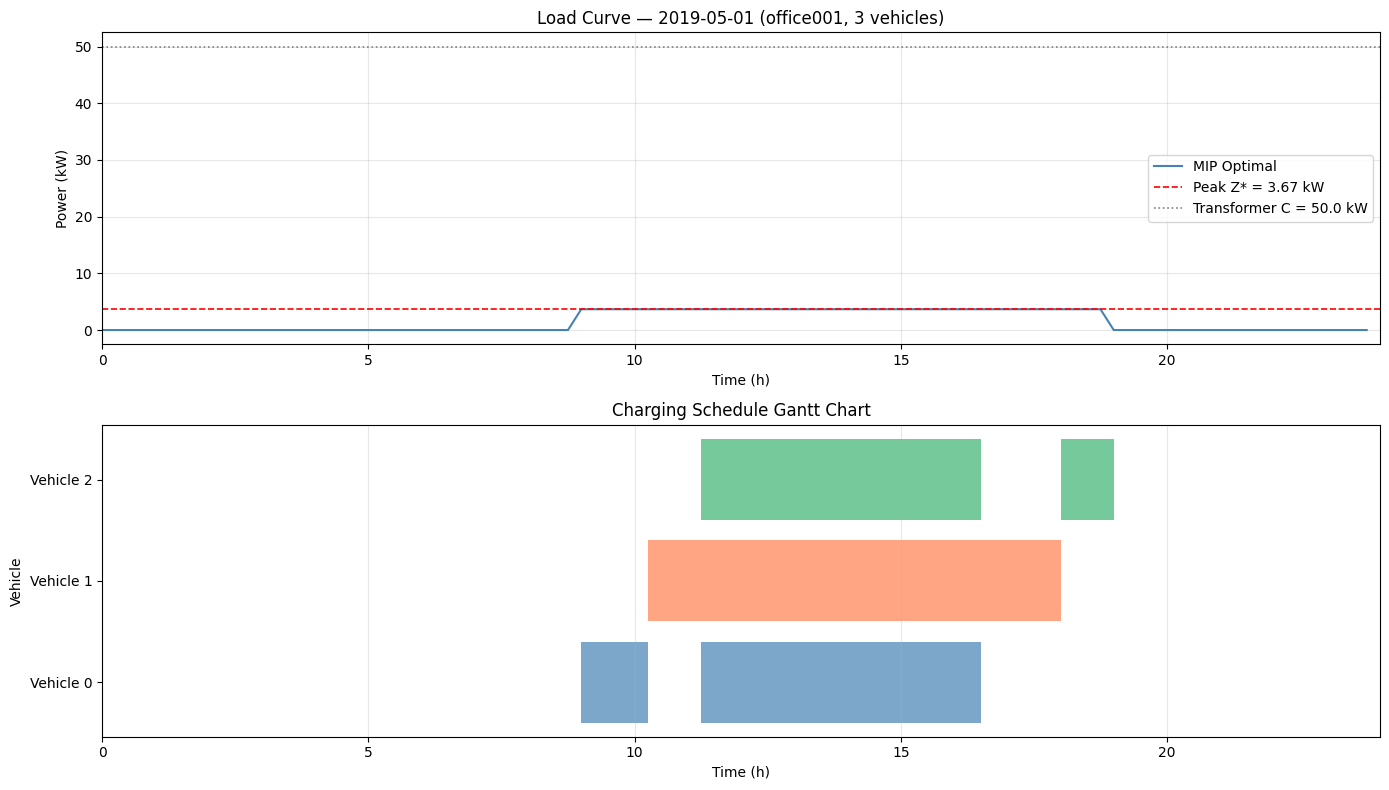

Saved: results/office001_2019-05-01_MIP.png


In [16]:
import matplotlib.pyplot as plt
import numpy as np
import os

os.makedirs('results', exist_ok=True)

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# ── 1. Load Curve ─────────────────────────────────────────
load = [sum(r[i, t].X for i in I) for t in T]  # .solution_value → .X
hours = [t * 0.25 for t in T]

axes[0].plot(hours, load, color='steelblue', linewidth=1.5, label='MIP Optimal')
axes[0].axhline(y=Z.X, color='red', linestyle='--',       # .solution_value → .X
                linewidth=1.2, label=f'Peak Z* = {Z.X:.2f} kW')
axes[0].axhline(y=C, color='gray', linestyle=':',
                linewidth=1.2, label=f'Transformer C = {C} kW')
axes[0].set_xlabel('Time (h)')
axes[0].set_ylabel('Power (kW)')
axes[0].set_title(f'Load Curve — {target} (office001, {len(I)} vehicles)')
axes[0].legend()
axes[0].set_xlim(0, 24)
axes[0].grid(alpha=0.3)

# ── 2. Gantt Chart ────────────────────────────────────────
colors = ['steelblue', 'coral', 'mediumseagreen']
for i in I:
    for t in range(a[i], d[i] + 1):
        rate = r[i, t].X                       # .solution_value → .X
        if rate > 0.01:
            axes[1].barh(
                y=i, width=DELTA_T, left=t * DELTA_T,
                color=colors[i % len(colors)], alpha=0.7, edgecolor='none'
            )

axes[1].set_xlabel('Time (h)')
axes[1].set_ylabel('Vehicle')
axes[1].set_title('Charging Schedule Gantt Chart')
axes[1].set_yticks(I)
axes[1].set_yticklabels([f'Vehicle {i}' for i in I])
axes[1].set_xlim(0, 24)
axes[1].grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('results/office001_2019-05-01_MIP.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: results/office001_2019-05-01_MIP.png")

### 휴리스틱 실행
- UC
- EDF
- RR

In [17]:
# ── 실행 ──────────────────────────────────────────────────
uc_result  = run_uc(inst)
edf_result = run_edf(inst)
rr_result  = run_rr(inst)

# ── 결과 비교 ─────────────────────────────────────────────
mip_peak = Z.X

print(f"{'Method':<6} | {'Peak (kW)':>10} | {'Satisfied':>10} | {'vs MIP':>10}")
print("-" * 46)
print(f"{'MIP':<6} | {mip_peak:>10.4f} | {len(I):>9}/{len(I)} | {'baseline':>10}")
print(f"{'UC':<6} | {uc_result['peak']:>10.4f} | {uc_result['satisfied']:>9}/{len(I)} | {uc_result['peak']/mip_peak:>9.2f}x")
print(f"{'EDF':<6} | {edf_result['peak']:>10.4f} | {edf_result['satisfied']:>9}/{len(I)} | {edf_result['peak']/mip_peak:>9.2f}x")
print(f"{'RR':<6} | {rr_result['peak']:>10.4f} | {rr_result['satisfied']:>9}/{len(I)} | {rr_result['peak']/mip_peak:>9.2f}x")

Method |  Peak (kW) |  Satisfied |     vs MIP
----------------------------------------------
MIP    |     3.6744 |         3/3 |   baseline
UC     |    14.4000 |         3/3 |      3.92x
EDF    |    14.4000 |         3/3 |      3.92x
RR     |    14.4000 |         3/3 |      3.92x


In [18]:
# 차량별 도착/출발 시간 확인
print("=== 차량별 체류 시간 ===")
for i in I:
    print(f"  차량 {i}: 슬롯 {a[i]}({a[i]*0.25:.1f}h) ~ {d[i]}({d[i]*0.25:.1f}h) | "
          f"필요 충전량: {e[i]:.2f} kWh | max_rate: {r_max[i]} kW")

=== 차량별 체류 시간 ===
  차량 0: 슬롯 36(9.0h) ~ 65(16.2h) | 필요 충전량: 5.76 kWh | max_rate: 7.2 kW
  차량 1: 슬롯 41(10.2h) ~ 71(17.8h) | 필요 충전량: 18.65 kWh | max_rate: 7.2 kW
  차량 2: 슬롯 45(11.2h) ~ 75(18.8h) | 필요 충전량: 12.34 kWh | max_rate: 7.2 kW


In [19]:
# UC에서 슬롯 45~65 구간 총 전력 확인
print("=== UC 슬롯 45~65 구간 전력 ===")
for t in range(45, 66):
    total = sum(uc_result['r'][i, t] for i in I)
    rates = [uc_result['r'][i, t] for i in I]
    print(f"  슬롯 {t} ({t*0.25:.2f}h): {total:.4f} kW | 차량별: {[round(x,2) for x in rates]}")

=== UC 슬롯 45~65 구간 전력 ===
  슬롯 45 (11.25h): 14.4000 kW | 차량별: [0.0, 7.2, 7.2]
  슬롯 46 (11.50h): 14.4000 kW | 차량별: [0.0, 7.2, 7.2]
  슬롯 47 (11.75h): 14.4000 kW | 차량별: [0.0, 7.2, 7.2]
  슬롯 48 (12.00h): 14.4000 kW | 차량별: [0.0, 7.2, 7.2]
  슬롯 49 (12.25h): 14.4000 kW | 차량별: [0.0, 7.2, 7.2]
  슬롯 50 (12.50h): 14.4000 kW | 차량별: [0.0, 7.2, 7.2]
  슬롯 51 (12.75h): 8.7240 kW | 차량별: [0.0, 2.58, 6.14]
  슬롯 52 (13.00h): 0.0000 kW | 차량별: [0.0, 0.0, 0.0]
  슬롯 53 (13.25h): 0.0000 kW | 차량별: [0.0, 0.0, 0.0]
  슬롯 54 (13.50h): 0.0000 kW | 차량별: [0.0, 0.0, 0.0]
  슬롯 55 (13.75h): 0.0000 kW | 차량별: [0.0, 0.0, 0.0]
  슬롯 56 (14.00h): 0.0000 kW | 차량별: [0.0, 0.0, 0.0]
  슬롯 57 (14.25h): 0.0000 kW | 차량별: [0.0, 0.0, 0.0]
  슬롯 58 (14.50h): 0.0000 kW | 차량별: [0.0, 0.0, 0.0]
  슬롯 59 (14.75h): 0.0000 kW | 차량별: [0.0, 0.0, 0.0]
  슬롯 60 (15.00h): 0.0000 kW | 차량별: [0.0, 0.0, 0.0]
  슬롯 61 (15.25h): 0.0000 kW | 차량별: [0.0, 0.0, 0.0]
  슬롯 62 (15.50h): 0.0000 kW | 차량별: [0.0, 0.0, 0.0]
  슬롯 63 (15.75h): 0.0000 kW | 차량별: [0.0, 0.0, 0.

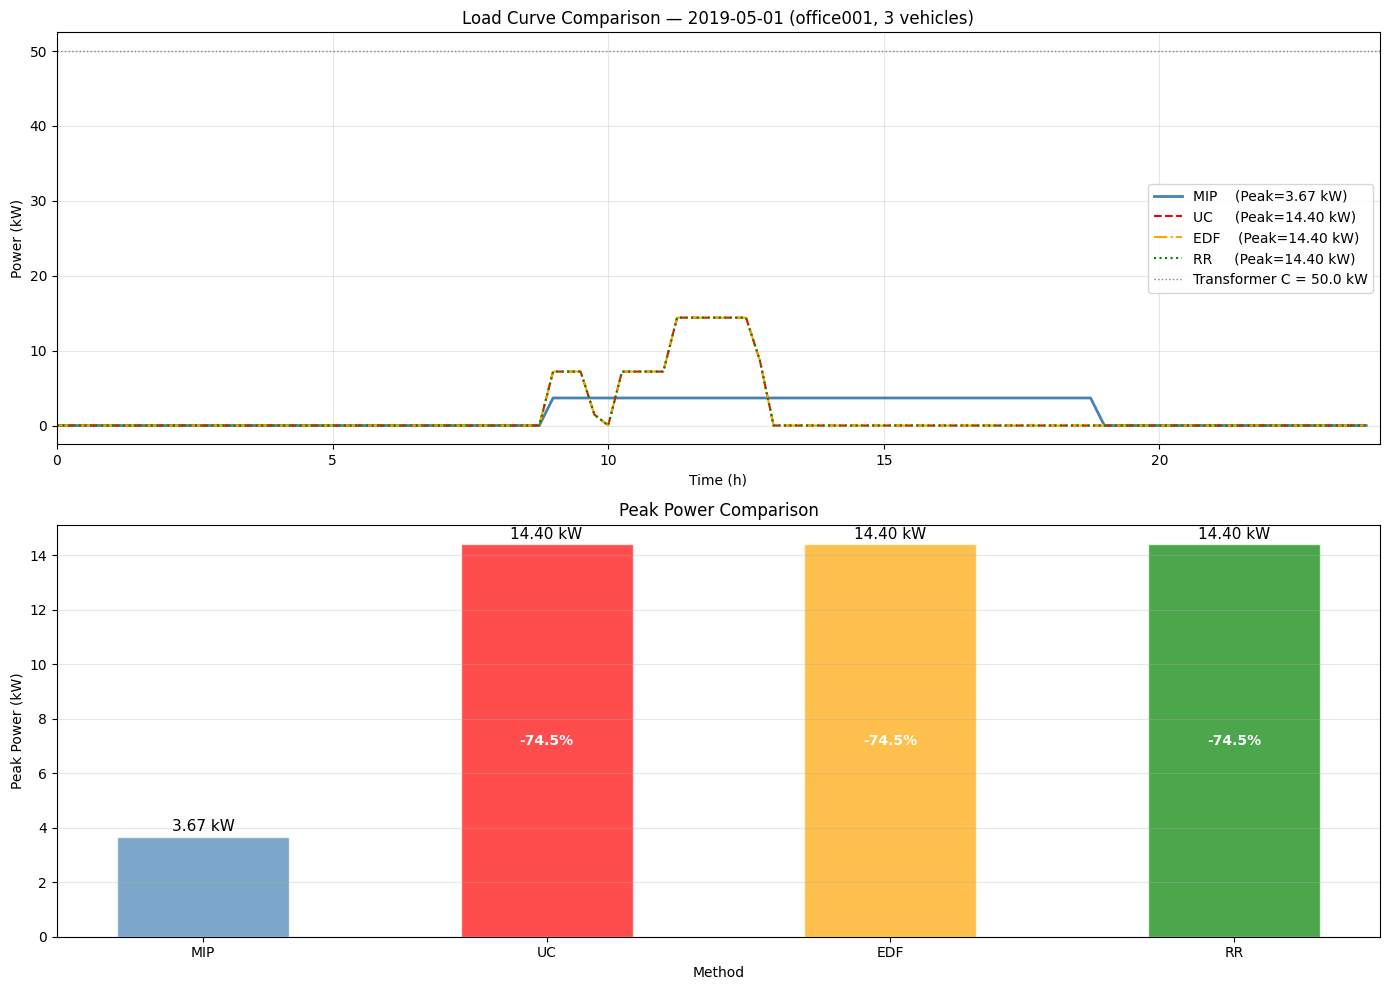

✅ Saved!


In [20]:
import matplotlib.pyplot as plt
import os

os.makedirs('results', exist_ok=True)

hours = [t * DELTA_T for t in T]
mip_load = [sum(r[i, t].X for i in I) for t in T]

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# ── 1. Load Curve 비교 ────────────────────────────────────
axes[0].plot(hours, mip_load,            color='steelblue',    linewidth=2,   label=f'MIP    (Peak={Z.X:.2f} kW)')
axes[0].plot(hours, uc_result['load'],   color='red',          linewidth=1.5, label=f'UC     (Peak={uc_result["peak"]:.2f} kW)', linestyle='--')
axes[0].plot(hours, edf_result['load'],  color='orange',       linewidth=1.5, label=f'EDF    (Peak={edf_result["peak"]:.2f} kW)', linestyle='-.')
axes[0].plot(hours, rr_result['load'],   color='green',        linewidth=1.5, label=f'RR     (Peak={rr_result["peak"]:.2f} kW)', linestyle=':')
axes[0].axhline(y=C, color='gray', linestyle=':', linewidth=1, label=f'Transformer C = {C} kW')
axes[0].set_xlabel('Time (h)')
axes[0].set_ylabel('Power (kW)')
axes[0].set_title(f'Load Curve Comparison — {target} (office001, {len(I)} vehicles)')
axes[0].legend()
axes[0].set_xlim(0, 24)
axes[0].grid(alpha=0.3)

# ── 2. Peak 비교 Bar Chart ────────────────────────────────
methods = ['MIP', 'UC', 'EDF', 'RR']
peaks   = [Z.X, uc_result['peak'], edf_result['peak'], rr_result['peak']]
colors  = ['steelblue', 'red', 'orange', 'green']

bars = axes[1].bar(methods, peaks, color=colors, alpha=0.7, edgecolor='white', width=0.5)
axes[1].set_xlabel('Method')
axes[1].set_ylabel('Peak Power (kW)')
axes[1].set_title('Peak Power Comparison')
axes[1].grid(alpha=0.3, axis='y')

# 막대 위에 값 표시
for bar, peak in zip(bars, peaks):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.1,
        f'{peak:.2f} kW',
        ha='center', va='bottom', fontsize=11
    )

# MIP 대비 감소율 표시
for bar, peak in zip(bars[1:], peaks[1:]):
    reduction = (peak - Z.X) / peak * 100
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() / 2,
        f'-{reduction:.1f}%',
        ha='center', va='center',
        fontsize=10, color='white', fontweight='bold'
    )

plt.tight_layout()
plt.savefig(f'results/office001_{target}_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved!")

In [21]:
import pandas as pd
import numpy as np
import gurobipy as gp
from gurobipy import GRB
from datetime import date
import time
import os

os.makedirs('results', exist_ok=True)

# ── 0. 데이터 로드 ────────────────────────────────────────
df_office = pd.read_csv('data/acn_office001_clean.csv')
df_office['date'] = pd.to_datetime(df_office['date']).dt.date

dates = sorted(df_office['date'].unique())
print(f"전체 날짜 수: {len(dates)}일")

# ── 1. 전체 날짜 루프 ─────────────────────────────────────
results = []

for idx, target in enumerate(dates):
    inst = make_instance(df_office, target, site='office001')
    if inst is None or inst['n_vehicles'] == 0:
        continue

    I, T    = inst['I'], inst['T']
    a, d    = inst['a'], inst['d']
    e       = inst['e']
    r_max   = inst['r_max']
    C       = inst['C']
    DELTA_T = inst['delta_t']

    # ── MIP ───────────────────────────────────────────────
    mdl = gp.Model('EV_office001')
    mdl.setParam('OutputFlag', 0)  # 로그 출력 끄기

    r = mdl.addVars(I, T, lb=0, name='r')
    y = mdl.addVars(I, T, vtype=GRB.BINARY, name='y')
    Z = mdl.addVar(lb=0, name='Z')

    mdl.setObjective(Z, GRB.MINIMIZE)

    for i in I:
        mdl.addConstr(
            gp.quicksum(r[i, t] * DELTA_T for t in range(a[i], d[i] + 1)) >= e[i]
        )
    for i in I:
        for t in T:
            mdl.addConstr(r[i, t] <= r_max[i] * y[i, t])
    for i in I:
        for t in T:
            if t < a[i] or t > d[i]:
                mdl.addConstr(y[i, t] == 0)
    for t in T:
        mdl.addConstr(gp.quicksum(r[i, t] for i in I) <= Z)
    for t in T:
        mdl.addConstr(gp.quicksum(r[i, t] for i in I) <= C)

    start = time.time()
    mdl.optimize()
    elapsed = time.time() - start

    if mdl.Status != GRB.OPTIMAL:
        print(f"  ⚠️ {target}: No optimal solution")
        continue

    mip_peak = Z.X
    mip_satisfied = sum(
        1 for i in I
        if sum(r[i, t].X * DELTA_T for t in range(a[i], d[i] + 1)) >= e[i] - 0.01
    )

    # ── UC / EDF / RR ─────────────────────────────────────
    uc  = run_uc(inst)
    edf = run_edf(inst)
    rr  = run_rr(inst)

    results.append({
        'date'          : target,
        'n_vehicles'    : inst['n_vehicles'],
        # MIP
        'mip_peak'      : round(mip_peak, 4),
        'mip_satisfied' : mip_satisfied,
        'mip_time'      : round(elapsed, 4),
        # UC
        'uc_peak'       : round(uc['peak'], 4),
        'uc_satisfied'  : uc['satisfied'],
        # EDF
        'edf_peak'      : round(edf['peak'], 4),
        'edf_satisfied' : edf['satisfied'],
        # RR
        'rr_peak'       : round(rr['peak'], 4),
        'rr_satisfied'  : rr['satisfied'],
    })

    # 진행 상황 출력
    if (idx + 1) % 50 == 0 or idx == len(dates) - 1:
        print(f"  진행: {idx+1}/{len(dates)} ({(idx+1)/len(dates)*100:.1f}%)")

# ── 2. 결과 저장 ───────────────────────────────────────────
df_results = pd.DataFrame(results)
df_results.to_csv('results/office001_all_results.csv', index=False)
print(f"\n✅ 완료! {len(df_results)}일 결과 저장 → results/office001_all_results.csv")

# ── 3. 요약 통계 ───────────────────────────────────────────
print(f"\n{'='*55}")
print(f"{'Method':<6} | {'Peak Mean':>10} | {'Peak Std':>9} | {'Peak Min':>9} | {'Peak Max':>9}")
print(f"-"*55)
for method, col in [('MIP','mip_peak'), ('UC','uc_peak'), ('EDF','edf_peak'), ('RR','rr_peak')]:
    print(f"{method:<6} | "
          f"{df_results[col].mean():>10.2f} | "
          f"{df_results[col].std():>9.2f} | "
          f"{df_results[col].min():>9.2f} | "
          f"{df_results[col].max():>9.2f}")

print(f"\n평균 계산 시간: {df_results['mip_time'].mean():.4f}s")
print(f"최대 계산 시간: {df_results['mip_time'].max():.4f}s")

# ── 4. Peak Reduction Rate ────────────────────────────────
print(f"\n{'='*40}")
print("Peak Reduction Rate (vs UC):")
for method, col in [('MIP','mip_peak'), ('EDF','edf_peak'), ('RR','rr_peak')]:
    reduction = ((df_results['uc_peak'] - df_results[col]) / df_results['uc_peak'] * 100).mean()
    print(f"  {method}: {reduction:.1f}% 감소")

전체 날짜 수: 544일
  진행: 50/544 (9.2%)
  진행: 100/544 (18.4%)
  진행: 150/544 (27.6%)
  진행: 200/544 (36.8%)
  진행: 250/544 (46.0%)
  진행: 300/544 (55.1%)
  진행: 350/544 (64.3%)
  진행: 400/544 (73.5%)
  ⚠️ 충전 불가 차량 1대 제거
  ⚠️ 충전 불가 차량 1대 제거
  진행: 450/544 (82.7%)
  ⚠️ 충전 불가 차량 1대 제거
  진행: 500/544 (91.9%)
  진행: 544/544 (100.0%)

✅ 완료! 543일 결과 저장 → results/office001_all_results.csv

Method |  Peak Mean |  Peak Std |  Peak Min |  Peak Max
-------------------------------------------------------
MIP    |       5.45 |      2.95 |      0.40 |     19.08
UC     |      13.07 |      7.30 |      3.04 |     43.20
EDF    |      13.07 |      7.30 |      3.04 |     43.20
RR     |      13.07 |      7.30 |      3.04 |     43.20

평균 계산 시간: 0.0025s
최대 계산 시간: 0.0060s

Peak Reduction Rate (vs UC):
  MIP: 56.5% 감소
  EDF: 0.0% 감소
  RR: 0.0% 감소


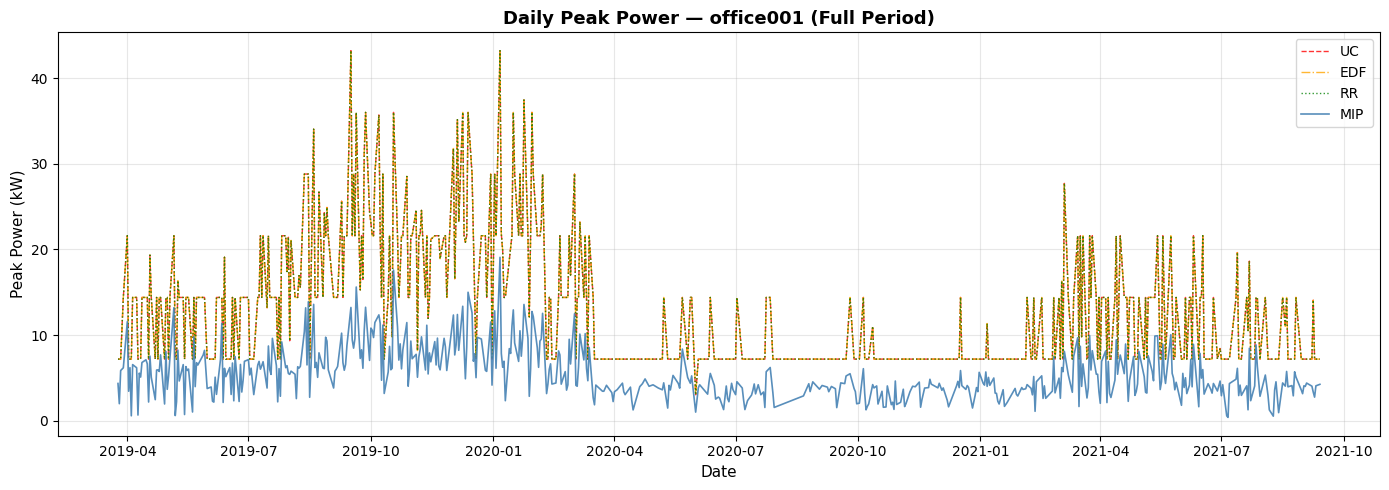

✅ Saved: figures/office001_peak_trend.png


C:\Users\geo48\AppData\Local\Temp\ipykernel_20996\1177879995.py:49: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labels, patch_artist=True,


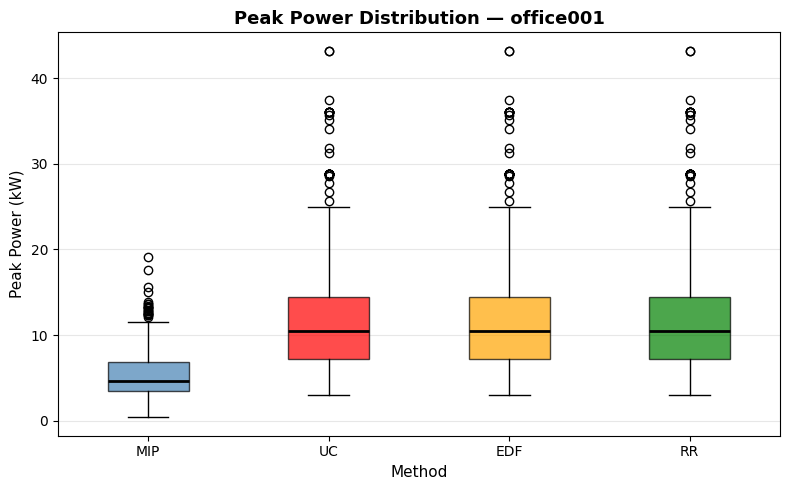

✅ Saved: figures/office001_boxplot.png


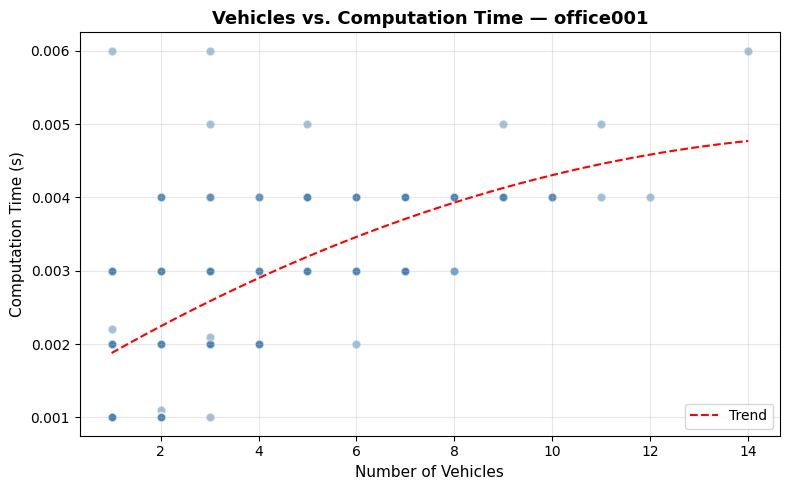

✅ Saved: figures/office001_scalability.png


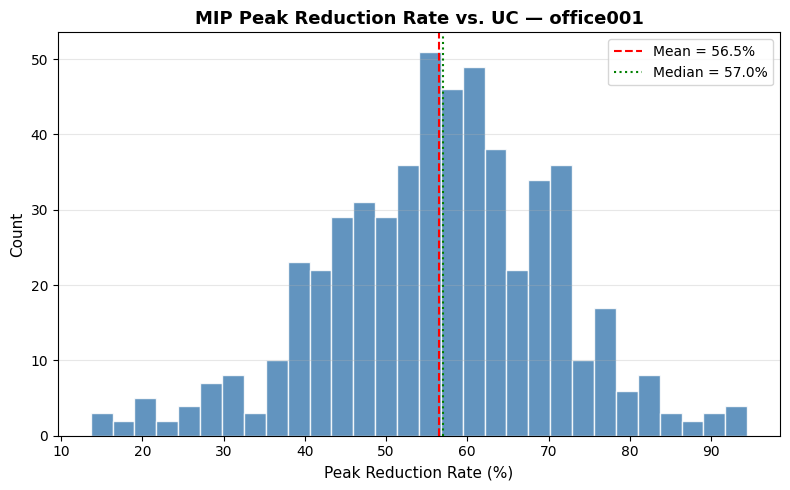

✅ Saved: figures/office001_reduction.png


In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import os

os.makedirs('figures', exist_ok=True)

# ── 데이터 로드 ────────────────────────────────────────────
df_results = pd.read_csv('results/office001_all_results.csv')
df_results['date'] = pd.to_datetime(df_results['date'])

# ── Figure 1: 날짜별 Peak 추이 ────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df_results['date'], df_results['uc_peak'],
        color='red', linewidth=1.0, linestyle='--', label='UC', alpha=0.8)
ax.plot(df_results['date'], df_results['edf_peak'],
        color='orange', linewidth=1.0, linestyle='-.', label='EDF', alpha=0.8)
ax.plot(df_results['date'], df_results['rr_peak'],
        color='green', linewidth=1.0, linestyle=':', label='RR', alpha=0.8)
ax.plot(df_results['date'], df_results['mip_peak'],
        color='steelblue', linewidth=1.2, label='MIP', alpha=0.9)

ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Peak Power (kW)', fontsize=11)
ax.set_title('Daily Peak Power — office001 (Full Period)', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('figures/office001_peak_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: figures/office001_peak_trend.png")


# ── Figure 2: Box Plot ────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))

data = [
    df_results['mip_peak'],
    df_results['uc_peak'],
    df_results['edf_peak'],
    df_results['rr_peak']
]
colors  = ['steelblue', 'red', 'orange', 'green']
labels  = ['MIP', 'UC', 'EDF', 'RR']

bp = ax.boxplot(data, labels=labels, patch_artist=True,
                medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_xlabel('Method', fontsize=11)
ax.set_ylabel('Peak Power (kW)', fontsize=11)
ax.set_title('Peak Power Distribution — office001', fontsize=13, fontweight='bold')
ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('figures/office001_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: figures/office001_boxplot.png")


# ── Figure 3: 차량 수 vs MIP 계산 시간 ───────────────────
fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(df_results['n_vehicles'], df_results['mip_time'],
           color='steelblue', alpha=0.5, edgecolors='white', s=40)

# 추세선
z = np.polyfit(df_results['n_vehicles'], df_results['mip_time'], 2)
p = np.poly1d(z)
x_line = np.linspace(df_results['n_vehicles'].min(),
                     df_results['n_vehicles'].max(), 100)
ax.plot(x_line, p(x_line), color='red', linewidth=1.5,
        linestyle='--', label='Trend')

ax.set_xlabel('Number of Vehicles', fontsize=11)
ax.set_ylabel('Computation Time (s)', fontsize=11)
ax.set_title('Vehicles vs. Computation Time — office001',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('figures/office001_scalability.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: figures/office001_scalability.png")


# ── Figure 4: Peak Reduction Rate 분포 ───────────────────
fig, ax = plt.subplots(figsize=(8, 5))

reduction = (df_results['uc_peak'] - df_results['mip_peak']) / df_results['uc_peak'] * 100

ax.hist(reduction, bins=30, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(reduction.mean(), color='red', linestyle='--', linewidth=1.5,
           label=f'Mean = {reduction.mean():.1f}%')
ax.axvline(reduction.median(), color='green', linestyle=':', linewidth=1.5,
           label=f'Median = {reduction.median():.1f}%')

ax.set_xlabel('Peak Reduction Rate (%)', fontsize=11)
ax.set_ylabel('Count', fontsize=11)
ax.set_title('MIP Peak Reduction Rate vs. UC — office001',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('figures/office001_reduction.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: figures/office001_reduction.png")

#### Caltech

In [44]:
# ── 전역 설정 ─────────────────────────────────────────────
DELTA_T   = 0.25   # 타임슬롯 크기 (15분 = 0.25h)
DAY_SLOTS = 96     # 하루 슬롯 수 (24h / 0.25h)

def make_instance(df, target_date, site='caltech'):
    """
    특정 날짜의 세션으로 MIP 인스턴스 생성
    
    Args:
        df          : 전처리된 세션 DataFrame
        target_date : 인스턴스 생성할 날짜 (date 객체)
        site        : 'caltech' or 'office001'
    
    Returns:
        instance (dict): MIP에 바로 넣을 수 있는 파라미터 딕셔너리
    """
    # 사이트별 변압기 용량
    C_dict = {
        'caltech'  : 150.0,
        'office001': 50.0,
    }
    C = C_dict.get(site, 150.0)

    # 날짜 필터링
    day_df = df[df['date'] == target_date].copy().reset_index(drop=True)

    if len(day_df) == 0:
        print(f"⚠️ {target_date}: 세션 없음")
        return None

    # slot_arrival, slot_departure 컬럼 없으면 생성
    if 'slot_arrival' not in day_df.columns:
        day_df['connection_time'] = pd.to_datetime(
            day_df['connection_time'], utc=True
        ).dt.tz_convert('America/Los_Angeles')
        day_df['disconnect_time'] = pd.to_datetime(
            day_df['disconnect_time'], utc=True
        ).dt.tz_convert('America/Los_Angeles')
        day_df['slot_arrival'] = day_df['connection_time'].apply(
            lambda dt: int((dt.hour * 60 + dt.minute) / (DELTA_T * 60))
        )
        day_df['slot_departure'] = day_df['disconnect_time'].apply(
            lambda dt: int((dt.hour * 60 + dt.minute) / (DELTA_T * 60))
        )
        # 자정 넘긴 경우 보정
        day_df['slot_departure'] = day_df.apply(
            lambda row: row['slot_departure'] + DAY_SLOTS
            if row['slot_departure'] <= row['slot_arrival']
            else row['slot_departure'],
            axis=1
        )

    # 파라미터 추출
    vehicles = day_df['session_id'].tolist()
    I        = list(range(len(vehicles)))
    T        = list(range(DAY_SLOTS))
    a        = day_df['slot_arrival'].tolist()
    d        = day_df['slot_departure'].tolist()
    e        = day_df['kwh_delivered'].tolist()
    r_max    = day_df['max_rate_kw'].tolist()

    # 슬롯 범위 보정
    a = [max(ai, 0)             for ai in a]
    d = [min(di, DAY_SLOTS - 1) for di in d]

    # 실현 가능성 체크
    infeasible = [
        i for i in I
        if r_max[i] * (d[i] - a[i] + 1) * DELTA_T < e[i]
    ]

    if infeasible:
        print(f"  ⚠️ {target_date}: 충전 불가 차량 {len(infeasible)}대 제거")
        mask     = [i for i in I if i not in infeasible]
        I        = list(range(len(mask)))
        a        = [a[i]        for i in mask]
        d        = [d[i]        for i in mask]
        e        = [e[i]        for i in mask]
        r_max    = [r_max[i]    for i in mask]
        vehicles = [vehicles[i] for i in mask]

    if len(I) == 0:
        print(f"  ⚠️ {target_date}: 유효한 차량 없음")
        return None

    return {
        'date'      : target_date,
        'site'      : site,
        'I'         : I,
        'T'         : T,
        'n_vehicles': len(I),
        'n_slots'   : DAY_SLOTS,
        'a'         : a,
        'd'         : d,
        'e'         : e,
        'r_max'     : r_max,
        'delta_t'   : DELTA_T,
        'C'         : C,
        'vehicles'  : vehicles,
    }

In [45]:
import gurobipy as gp
from gurobipy import GRB
from datetime import date
import pandas as pd
import time

# ── 0. 인스턴스 로드 ──────────────────────────────────────
df = pd.read_csv('data/acn_caltech_clean.csv')
df['date'] = pd.to_datetime(df['date']).dt.date

target = date(2018, 5, 1)
inst = make_instance(df, target, site='caltech')

I       = inst['I']
T       = inst['T']
a       = inst['a']
d       = inst['d']
e       = inst['e']
r_max   = inst['r_max']
C       = inst['C']
DELTA_T = inst['delta_t']

print(f"날짜: {target}")
print(f"차량 수: {len(I)}대, 슬롯 수: {len(T)}개")

# ── 1. 모델 생성 ──────────────────────────────────────────
mdl = gp.Model('EV_Charging_caltech')
mdl.setParam('OutputFlag', 1)

# ── 2. 결정변수 ───────────────────────────────────────────
r = mdl.addVars(I, T, lb=0, name='r')
y = mdl.addVars(I, T, vtype=GRB.BINARY, name='y')
Z = mdl.addVar(lb=0, name='Z')

# ── 3. 목적함수 ───────────────────────────────────────────
mdl.setObjective(Z, GRB.MINIMIZE)

# ── 4. 제약조건 ───────────────────────────────────────────
for i in I:
    mdl.addConstr(
        gp.quicksum(r[i, t] * DELTA_T for t in range(a[i], d[i] + 1)) >= e[i],
        name=f'C1_{i}'
    )

for i in I:
    for t in T:
        mdl.addConstr(r[i, t] <= r_max[i] * y[i, t], name=f'C2_{i}_{t}')

for i in I:
    for t in T:
        if t < a[i] or t > d[i]:
            mdl.addConstr(y[i, t] == 0, name=f'C3_{i}_{t}')

for t in T:
    mdl.addConstr(gp.quicksum(r[i, t] for i in I) <= Z, name=f'C4_{t}')

for t in T:
    mdl.addConstr(gp.quicksum(r[i, t] for i in I) <= C, name=f'C5_{t}')

# ── 5. 모델 정보 출력 ─────────────────────────────────────
mdl.update()
print(f"\n=== Model Info ===")
print(f"Variables  : {mdl.NumVars:,}")
print(f"Constraints: {mdl.NumConstrs:,}")
print(f"  Continuous: {mdl.NumVars - mdl.NumBinVars:,}")
print(f"  Binary    : {mdl.NumBinVars:,}")

# ── 6. 풀기 ───────────────────────────────────────────────
start = time.time()
mdl.optimize()
elapsed = time.time() - start

# ── 7. 결과 출력 ──────────────────────────────────────────
if mdl.Status == GRB.OPTIMAL:
    print(f"\n=== Solution ===")
    print(f"Status    : OPTIMAL")
    print(f"Peak Z*   : {Z.X:.2f} kW")
    print(f"Solve time: {elapsed:.2f}s")

    satisfied = sum(
        1 for i in I
        if sum(r[i, t].X * DELTA_T
               for t in range(a[i], d[i] + 1)) >= e[i] - 0.01
    )
    print(f"\n=== Energy Fulfillment Check ===")
    print(f"  {satisfied}/{len(I)} vehicles fully charged ✅")
else:
    print(f"❌ No solution found")
    print(f"Status: {mdl.Status}")

날짜: 2018-05-01
차량 수: 52대, 슬롯 수: 96개
Set parameter OutputFlag to value 1

=== Model Info ===
Variables  : 9,985
Constraints: 8,903
  Continuous: 4,993
  Binary    : 4,992
Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (win64 - Windows 11+.0 (26200.2))

CPU model: Intel(R) Core(TM) Ultra 9 275HX, instruction set [SSE2|AVX|AVX2]
Thread count: 24 physical cores, 24 logical processors, using up to 24 threads

Academic license 2809695 - for non-commercial use only - registered to do___@postech.ac.kr
Optimize a model with 8903 rows, 9985 columns and 25056 nonzeros (Min)
Model fingerprint: 0xadf7e55e
Model has 1 linear objective coefficients
Variable types: 4993 continuous, 4992 integer (4992 binary)
Coefficient statistics:
  Matrix range     [3e-01, 2e+01]
  Objective range  [1e+00, 1e+00]
  Bounds range     [1e+00, 1e+00]
  RHS range        [6e-01, 2e+02]

Found heuristic solution: objective 78.6500000
Presolve removed 8769 rows and 9094 columns
Presolve time: 0.01s
Presolved: 134 rows, 89

In [46]:
df = pd.read_csv('data/acn_caltech.csv')
df['connection_time']    = pd.to_datetime(df['connection_time'],    utc=True).dt.tz_convert('America/Los_Angeles')
df['disconnect_time']    = pd.to_datetime(df['disconnect_time'],    utc=True).dt.tz_convert('America/Los_Angeles')
df['done_charging_time'] = pd.to_datetime(df['done_charging_time'], utc=True).dt.tz_convert('America/Los_Angeles')
print(f"1. 로드 후:            {len(df):,}개")

df['duration_hr'] = (df['disconnect_time'] - df['connection_time']).dt.total_seconds() / 3600
df['date'] = df['connection_time'].dt.date
print(f"2. 파생 컬럼 후:       {len(df):,}개")

df = df[df['duration_hr'] >= 0.25]
print(f"3. 15분 미만 제거 후:  {len(df):,}개")

df = df[df['duration_hr'] <= 24]
print(f"4. 24시간 초과 제거 후:{len(df):,}개")

df = df[df['kwh_delivered'] > 0]
print(f"5. 충전량 0 이하 후:   {len(df):,}개")

df = df[df['disconnect_time'] > df['connection_time']]
print(f"6. 시간 역전 제거 후:  {len(df):,}개")

df['max_rate_kw'] = df['max_rate_kw'].fillna(7.2)
df['done_charging_time'] = df['done_charging_time'].fillna(df['disconnect_time'])
print(f"7. 결측치 처리 후:     {len(df):,}개")

# 타임슬롯 이산화
# ...

df.to_csv('data/acn_caltech_clean.csv', index=False)
print(f"\n✅ 최종 저장: {len(df):,}개")

1. 로드 후:            31,399개
2. 파생 컬럼 후:       31,399개
3. 15분 미만 제거 후:  30,980개
4. 24시간 초과 제거 후:30,721개
5. 충전량 0 이하 후:   30,721개
6. 시간 역전 제거 후:  30,721개
7. 결측치 처리 후:     30,721개

✅ 최종 저장: 30,721개


In [47]:
df_clean = pd.read_csv('data/acn_caltech_clean.csv')
df_clean['date'] = pd.to_datetime(df_clean['date']).dt.date

daily = df_clean.groupby('date').size().reset_index(name='count')
print(f"전체 세션 수: {len(df_clean):,}개")
print(f"평균 차량 수: {daily['count'].mean():.1f}대")
print(f"최대 차량 수: {daily['count'].max()}대")
print(f"\n차량 많은 날 Top 5:")
print(daily.nlargest(5, 'count'))

전체 세션 수: 30,721개
평균 차량 수: 28.4대
최대 차량 수: 105대

차량 많은 날 Top 5:
           date  count
139  2018-09-11    105
153  2018-09-25    101
160  2018-10-02    100
189  2018-10-31     99
152  2018-09-24     96


In [48]:
from datetime import date

# 적당한 규모 날짜로 테스트 (너무 많으면 오래 걸림)
# 50대 전후 날짜 찾기
mid_days = daily[(daily['count'] >= 40) & (daily['count'] <= 60)]
print(mid_days.head(10))

          date  count
0   2018-04-25     58
1   2018-04-26     47
2   2018-04-27     50
5   2018-04-30     52
6   2018-05-01     52
7   2018-05-02     57
12  2018-05-07     59
13  2018-05-08     59
16  2018-05-11     58
37  2018-06-01     60


In [49]:
print(f"차량 수: {inst['n_vehicles']}대")
print(f"결정변수 수: {inst['n_vehicles'] * 96 * 2 + 1:,}개")  # r, y 변수 + Z

차량 수: 52대
결정변수 수: 9,985개


In [51]:
import gurobipy as gp
from gurobipy import GRB
from datetime import date
import pandas as pd
import time

# ── 0. 인스턴스 로드 ──────────────────────────────────────
df = pd.read_csv('data/acn_caltech_clean.csv')
df['date'] = pd.to_datetime(df['date']).dt.date

target = date(2018, 5, 1)
inst = make_instance(df, target, site='caltech')  # df_clean → df 수정

I       = inst['I']
T       = inst['T']
a       = inst['a']
d       = inst['d']
e       = inst['e']
r_max   = inst['r_max']
C       = inst['C']
DELTA_T = inst['delta_t']

print(f"날짜: {target}")
print(f"차량 수: {len(I)}대, 슬롯 수: {len(T)}개")

# ── 1. 모델 생성 ──────────────────────────────────────────
mdl = gp.Model('EV_Charging_caltech')
mdl.setParam('OutputFlag', 1)

# ── 2. 결정변수 ───────────────────────────────────────────
r = mdl.addVars(I, T, lb=0, name='r')
y = mdl.addVars(I, T, vtype=GRB.BINARY, name='y')
Z = mdl.addVar(lb=0, name='Z')

# ── 3. 목적함수 ───────────────────────────────────────────
mdl.setObjective(Z, GRB.MINIMIZE)

# ── 4. 제약조건 ───────────────────────────────────────────
for i in I:
    mdl.addConstr(
        gp.quicksum(r[i, t] * DELTA_T for t in range(a[i], d[i] + 1)) >= e[i],
        name=f'C1_{i}'
    )
for i in I:
    for t in T:
        mdl.addConstr(r[i, t] <= r_max[i] * y[i, t], name=f'C2_{i}_{t}')
for i in I:
    for t in T:
        if t < a[i] or t > d[i]:
            mdl.addConstr(y[i, t] == 0, name=f'C3_{i}_{t}')
for t in T:
    mdl.addConstr(gp.quicksum(r[i, t] for i in I) <= Z, name=f'C4_{t}')
for t in T:
    mdl.addConstr(gp.quicksum(r[i, t] for i in I) <= C, name=f'C5_{t}')

# ── 5. 모델 정보 출력 ─────────────────────────────────────
mdl.update()
print(f"\n=== Model Info ===")
print(f"Variables  : {mdl.NumVars:,}")
print(f"Constraints: {mdl.NumConstrs:,}")
print(f"  Continuous: {mdl.NumVars - mdl.NumBinVars:,}")
print(f"  Binary    : {mdl.NumBinVars:,}")

# ── 6. 풀기 ───────────────────────────────────────────────
start = time.time()
mdl.optimize()
elapsed = time.time() - start

# ── 7. 결과 출력 ──────────────────────────────────────────
if mdl.Status == GRB.OPTIMAL:
    print(f"\n=== Solution ===")
    print(f"Status    : OPTIMAL")
    print(f"Peak Z*   : {Z.X:.2f} kW")
    print(f"Solve time: {elapsed:.2f}s")

    satisfied = sum(
        1 for i in I
        if sum(r[i, t].X * DELTA_T
               for t in range(a[i], d[i] + 1)) >= e[i] - 0.01
    )
    print(f"\n=== Energy Fulfillment Check ===")
    print(f"  {satisfied}/{len(I)} vehicles fully charged ✅")
else:
    print(f"❌ No solution: {mdl.Status}")

날짜: 2018-05-01
차량 수: 52대, 슬롯 수: 96개
Set parameter OutputFlag to value 1

=== Model Info ===
Variables  : 9,985
Constraints: 8,903
  Continuous: 4,993
  Binary    : 4,992
Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (win64 - Windows 11+.0 (26200.2))

CPU model: Intel(R) Core(TM) Ultra 9 275HX, instruction set [SSE2|AVX|AVX2]
Thread count: 24 physical cores, 24 logical processors, using up to 24 threads

Academic license 2809695 - for non-commercial use only - registered to do___@postech.ac.kr
Optimize a model with 8903 rows, 9985 columns and 25056 nonzeros (Min)
Model fingerprint: 0xadf7e55e
Model has 1 linear objective coefficients
Variable types: 4993 continuous, 4992 integer (4992 binary)
Coefficient statistics:
  Matrix range     [3e-01, 2e+01]
  Objective range  [1e+00, 1e+00]
  Bounds range     [1e+00, 1e+00]
  RHS range        [6e-01, 2e+02]

Found heuristic solution: objective 78.6500000
Presolve removed 8769 rows and 9094 columns
Presolve time: 0.00s
Presolved: 134 rows, 89

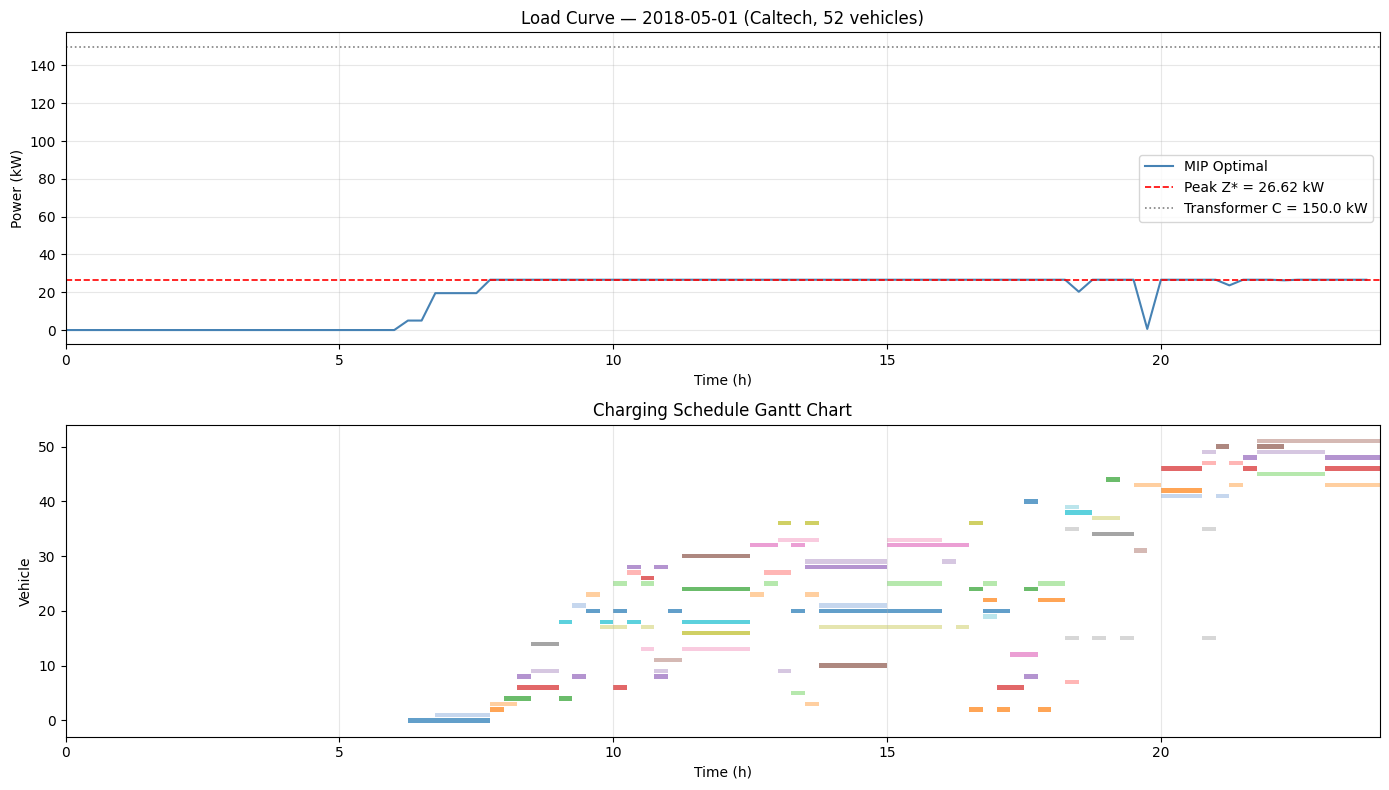

✅ Saved!


In [52]:
import matplotlib.pyplot as plt
import os

os.makedirs('results', exist_ok=True)

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Load Curve
load = [sum(r[i, t].X for i in I) for t in T]
hours = [t * 0.25 for t in T]

axes[0].plot(hours, load, color='steelblue', linewidth=1.5, label='MIP Optimal')
axes[0].axhline(y=Z.X, color='red', linestyle='--',
                linewidth=1.2, label=f'Peak Z* = {Z.X:.2f} kW')
axes[0].axhline(y=C, color='gray', linestyle=':',
                linewidth=1.2, label=f'Transformer C = {C} kW')
axes[0].set_xlabel('Time (h)')
axes[0].set_ylabel('Power (kW)')
axes[0].set_title(f'Load Curve — {target} (Caltech, {len(I)} vehicles)')
axes[0].legend()
axes[0].set_xlim(0, 24)
axes[0].grid(alpha=0.3)

# Gantt Chart
colors = plt.cm.tab20.colors
for i in I:
    for t in range(a[i], d[i] + 1):
        rate = r[i, t].X
        if rate > 0.01:
            axes[1].barh(
                y=i, width=DELTA_T, left=t * DELTA_T,
                color=colors[i % len(colors)], alpha=0.7, edgecolor='none'
            )

axes[1].set_xlabel('Time (h)')
axes[1].set_ylabel('Vehicle')
axes[1].set_title('Charging Schedule Gantt Chart')
axes[1].set_xlim(0, 24)
axes[1].grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig(f'results/caltech_{target}_MIP.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved!")

### 휴리스틱 실행

In [56]:
import pandas as pd
import numpy as np
import gurobipy as gp
from gurobipy import GRB
from datetime import date
import time
import os

os.makedirs('results', exist_ok=True)

# ── 0. 데이터 로드 ────────────────────────────────────────
df_caltech = pd.read_csv('data/acn_caltech_clean.csv')
df_caltech['date'] = pd.to_datetime(df_caltech['date']).dt.date

dates = sorted(df_caltech['date'].unique())
print(f"전체 날짜 수: {len(dates)}일")

# ── 1. 전체 날짜 루프 ─────────────────────────────────────
results = []
failed  = []

for idx, target in enumerate(dates):
    inst = make_instance(df_caltech, target, site='caltech')
    if inst is None or inst['n_vehicles'] == 0:
        continue

    I, T    = inst['I'], inst['T']
    a, d    = inst['a'], inst['d']
    e       = inst['e']
    r_max   = inst['r_max']
    C       = inst['C']
    DELTA_T = inst['delta_t']

    # ── MIP ───────────────────────────────────────────────
    try:
        mdl = gp.Model('EV_caltech')
        mdl.setParam('OutputFlag', 0)    # 로그 끄기
        mdl.setParam('TimeLimit', 300)   # 최대 5분 제한

        r = mdl.addVars(I, T, lb=0, name='r')
        y = mdl.addVars(I, T, vtype=GRB.BINARY, name='y')
        Z = mdl.addVar(lb=0, name='Z')

        mdl.setObjective(Z, GRB.MINIMIZE)

        for i in I:
            mdl.addConstr(
                gp.quicksum(r[i, t] * DELTA_T for t in range(a[i], d[i] + 1)) >= e[i]
            )
        for i in I:
            for t in T:
                mdl.addConstr(r[i, t] <= r_max[i] * y[i, t])
        for i in I:
            for t in T:
                if t < a[i] or t > d[i]:
                    mdl.addConstr(y[i, t] == 0)
        for t in T:
            mdl.addConstr(gp.quicksum(r[i, t] for i in I) <= Z)
        for t in T:
            mdl.addConstr(gp.quicksum(r[i, t] for i in I) <= C)

        start = time.time()
        mdl.optimize()
        elapsed = time.time() - start

        # TimeLimit 내 최적해 못 찾으면 스킵
        if mdl.Status not in [GRB.OPTIMAL, GRB.TIME_LIMIT]:
            failed.append(target)
            continue

        mip_peak = Z.X
        mip_gap  = mdl.MIPGap if mdl.Status == GRB.TIME_LIMIT else 0.0
        mip_satisfied = sum(
            1 for i in I
            if sum(r[i, t].X * DELTA_T for t in range(a[i], d[i] + 1)) >= e[i] - 0.01
        )

    except Exception as ex:
        print(f"  ❌ {target}: {ex}")
        failed.append(target)
        continue

    # ── UC / EDF / RR ─────────────────────────────────────
    uc  = run_uc(inst)
    edf = run_edf(inst)
    rr  = run_rr(inst)

    results.append({
        'date'          : target,
        'n_vehicles'    : inst['n_vehicles'],
        # MIP
        'mip_peak'      : round(mip_peak, 4),
        'mip_satisfied' : mip_satisfied,
        'mip_time'      : round(elapsed, 4),
        'mip_gap'       : round(mip_gap, 6),
        # UC
        'uc_peak'       : round(uc['peak'], 4),
        'uc_satisfied'  : uc['satisfied'],
        # EDF
        'edf_peak'      : round(edf['peak'], 4),
        'edf_satisfied' : edf['satisfied'],
        # RR
        'rr_peak'       : round(rr['peak'], 4),
        'rr_satisfied'  : rr['satisfied'],
    })

    # 진행 상황 출력 + 중간 저장
    if (idx + 1) % 50 == 0 or idx == len(dates) - 1:
        elapsed_total = sum(r['mip_time'] for r in results)
        print(f"  진행: {idx+1}/{len(dates)} ({(idx+1)/len(dates)*100:.1f}%) "
              f"| 누적 MIP 시간: {elapsed_total:.1f}s")
        pd.DataFrame(results).to_csv(
            'results/caltech_all_results.csv', index=False
        )

# ── 2. 최종 저장 ───────────────────────────────────────────
df_results = pd.DataFrame(results)
df_results.to_csv('results/caltech_all_results.csv', index=False)
print(f"\n✅ 완료! {len(df_results)}일 결과 저장")
print(f"⚠️  실패한 날짜: {len(failed)}일 → {failed[:5]}{'...' if len(failed)>5 else ''}")

# ── 3. 요약 통계 ───────────────────────────────────────────
print(f"\n{'='*60}")
print(f"{'Method':<6} | {'Peak Mean':>10} | {'Peak Std':>9} | {'Peak Min':>9} | {'Peak Max':>9}")
print("-"*60)
for method, col in [('MIP','mip_peak'), ('UC','uc_peak'),
                    ('EDF','edf_peak'), ('RR','rr_peak')]:
    print(f"{method:<6} | "
          f"{df_results[col].mean():>10.2f} | "
          f"{df_results[col].std():>9.2f} | "
          f"{df_results[col].min():>9.2f} | "
          f"{df_results[col].max():>9.2f}")

print(f"\n평균 계산 시간: {df_results['mip_time'].mean():.4f}s")
print(f"최대 계산 시간: {df_results['mip_time'].max():.4f}s")

print(f"\n{'='*40}")
print("Peak Reduction Rate (vs UC):")
for method, col in [('MIP','mip_peak'), ('EDF','edf_peak'), ('RR','rr_peak')]:
    reduction = (
        (df_results['uc_peak'] - df_results[col]) / df_results['uc_peak'] * 100
    ).mean()
    print(f"  {method}: {reduction:.1f}% 감소")

전체 날짜 수: 1081일
  ⚠️ 2018-04-25: 충전 불가 차량 1대 제거
  ⚠️ 2018-04-27: 충전 불가 차량 3대 제거
  ⚠️ 2018-04-29: 충전 불가 차량 1대 제거
  ⚠️ 2018-04-30: 충전 불가 차량 2대 제거
  ⚠️ 2018-05-04: 충전 불가 차량 2대 제거
  ⚠️ 2018-05-05: 충전 불가 차량 1대 제거
  ⚠️ 2018-05-07: 충전 불가 차량 1대 제거
  ⚠️ 2018-05-08: 충전 불가 차량 1대 제거
  ⚠️ 2018-05-10: 충전 불가 차량 1대 제거
  ⚠️ 2018-05-11: 충전 불가 차량 1대 제거
  ⚠️ 2018-05-18: 충전 불가 차량 2대 제거
  ⚠️ 2018-05-19: 충전 불가 차량 1대 제거
  ⚠️ 2018-05-22: 충전 불가 차량 1대 제거
  ⚠️ 2018-05-26: 충전 불가 차량 1대 제거
  ⚠️ 2018-05-31: 충전 불가 차량 1대 제거
  ⚠️ 2018-06-01: 충전 불가 차량 1대 제거
  ⚠️ 2018-06-02: 충전 불가 차량 1대 제거
  ⚠️ 2018-06-08: 충전 불가 차량 1대 제거
  ⚠️ 2018-06-10: 충전 불가 차량 1대 제거
  ⚠️ 2018-06-11: 충전 불가 차량 1대 제거
  진행: 50/1081 (4.6%) | 누적 MIP 시간: 1.2s
  ⚠️ 2018-06-19: 충전 불가 차량 2대 제거
  ⚠️ 2018-06-21: 충전 불가 차량 1대 제거
  ⚠️ 2018-06-22: 충전 불가 차량 1대 제거
  ⚠️ 2018-06-24: 충전 불가 차량 1대 제거
  ⚠️ 2018-06-29: 충전 불가 차량 1대 제거
  ⚠️ 2018-06-30: 충전 불가 차량 2대 제거
  ⚠️ 2018-07-02: 충전 불가 차량 1대 제거
  ⚠️ 2018-07-05: 충전 불가 차량 1대 제거
  ⚠️ 2018-07-06: 충전 불가 차량 3대 제거
  ⚠️ 2018-07-07: 충

In [57]:
df_caltech = pd.read_csv('data/acn_caltech_clean.csv')
df_caltech['date'] = pd.to_datetime(df_caltech['date']).dt.date

dates = sorted(df_caltech['date'].unique())
print(f"전체 날짜 수: {len(dates)}일")
print(f"기간: {dates[0]} ~ {dates[-1]}")

# 결과 파일 확인
df_results = pd.read_csv('results/caltech_all_results.csv')
print(f"\n결과 저장된 날짜 수: {len(df_results)}일")
print(f"결과 기간: {df_results['date'].min()} ~ {df_results['date'].max()}")

# 날짜별 세션 수 0인 날 확인
daily = df_caltech.groupby('date').size().reset_index(name='count')
print(f"\n세션 수 0인 날: {(daily['count'] == 0).sum()}일")
print(f"날짜 수 - 결과 수 = {len(dates) - len(df_results)}일 차이")

전체 날짜 수: 1081일
기간: 2018-04-25 ~ 2021-09-13

결과 저장된 날짜 수: 1078일
결과 기간: 2018-04-25 ~ 2021-09-13

세션 수 0인 날: 0일
날짜 수 - 결과 수 = 3일 차이


In [58]:
df_results = pd.read_csv('results/caltech_all_results.csv')
print(f"저장된 날짜 수: {len(df_results)}일")
print(f"기간: {df_results['date'].min()} ~ {df_results['date'].max()}")
print(f"\n=== 요약 통계 ===")
print(f"{'Method':<6} | {'Peak Mean':>10} | {'Peak Std':>9} | {'Peak Min':>9} | {'Peak Max':>9}")
print("-"*60)
for method, col in [('MIP','mip_peak'), ('UC','uc_peak'),
                    ('EDF','edf_peak'), ('RR','rr_peak')]:
    print(f"{method:<6} | "
          f"{df_results[col].mean():>10.2f} | "
          f"{df_results[col].std():>9.2f} | "
          f"{df_results[col].min():>9.2f} | "
          f"{df_results[col].max():>9.2f}")

print(f"\n평균 계산 시간: {df_results['mip_time'].mean():.4f}s")
print(f"최대 계산 시간: {df_results['mip_time'].max():.4f}s")
print(f"\nPeak Reduction Rate (vs UC):")
for method, col in [('MIP','mip_peak'), ('EDF','edf_peak'), ('RR','rr_peak')]:
    reduction = (
        (df_results['uc_peak'] - df_results[col]) / df_results['uc_peak'] * 100
    ).mean()
    print(f"  {method}: {reduction:.1f}% 감소")

저장된 날짜 수: 1078일
기간: 2018-04-25 ~ 2021-09-13

=== 요약 통계 ===
Method |  Peak Mean |  Peak Std |  Peak Min |  Peak Max
------------------------------------------------------------
MIP    |      16.80 |     12.71 |      0.18 |     56.59
UC     |      74.57 |     60.33 |      3.00 |    327.52
EDF    |      69.33 |     49.21 |      3.00 |    150.00
RR     |      65.10 |     43.62 |      3.00 |    150.00

평균 계산 시간: 0.0120s
최대 계산 시간: 0.1732s

Peak Reduction Rate (vs UC):
  MIP: 75.9% 감소
  EDF: 2.4% 감소
  RR: 5.4% 감소


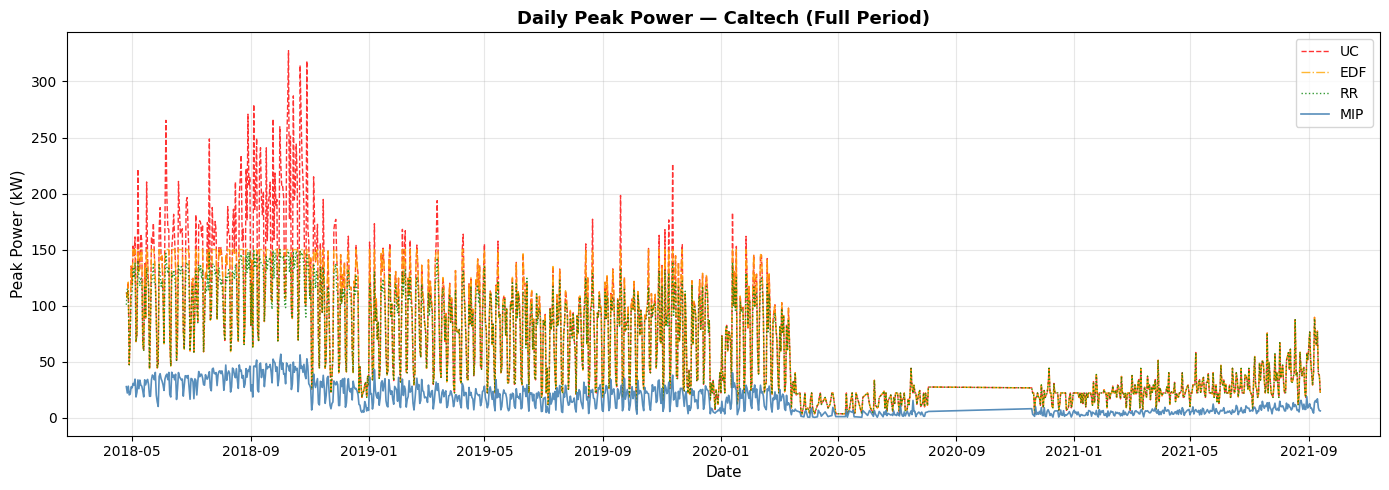

✅ Saved: figures/caltech_peak_trend.png


C:\Users\geo48\AppData\Local\Temp\ipykernel_20996\2310004545.py:45: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labels, patch_artist=True,


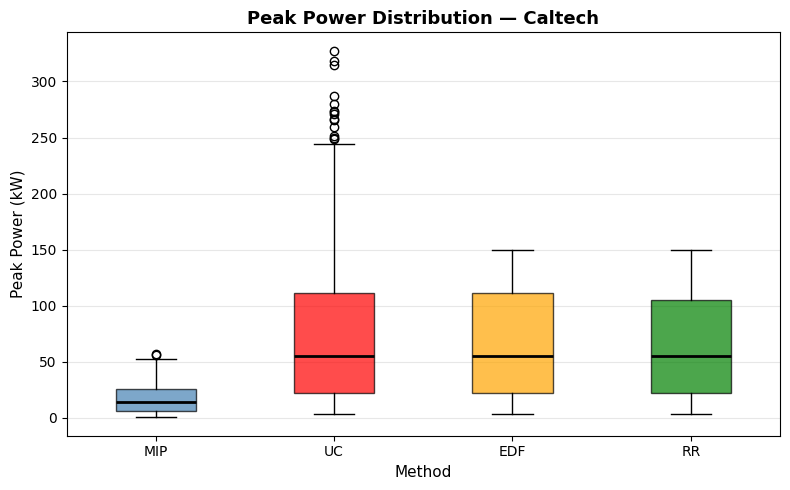

✅ Saved: figures/caltech_boxplot.png


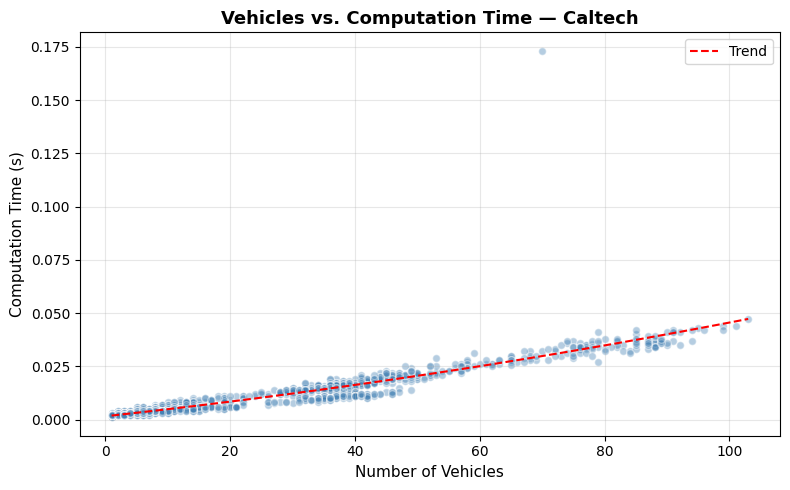

✅ Saved: figures/caltech_scalability.png


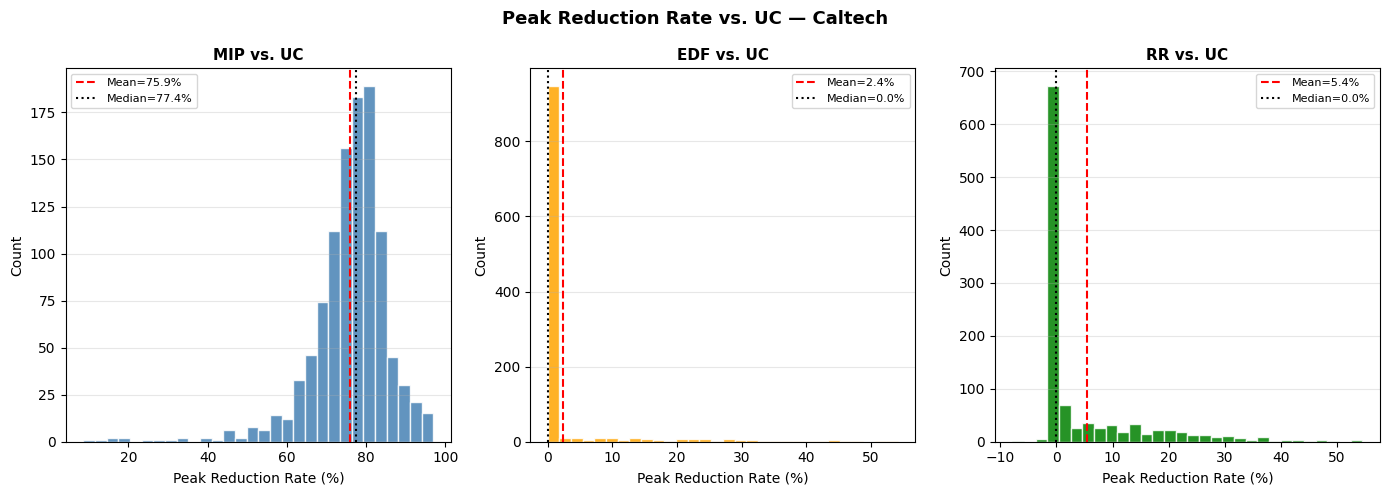

✅ Saved: figures/caltech_reduction.png


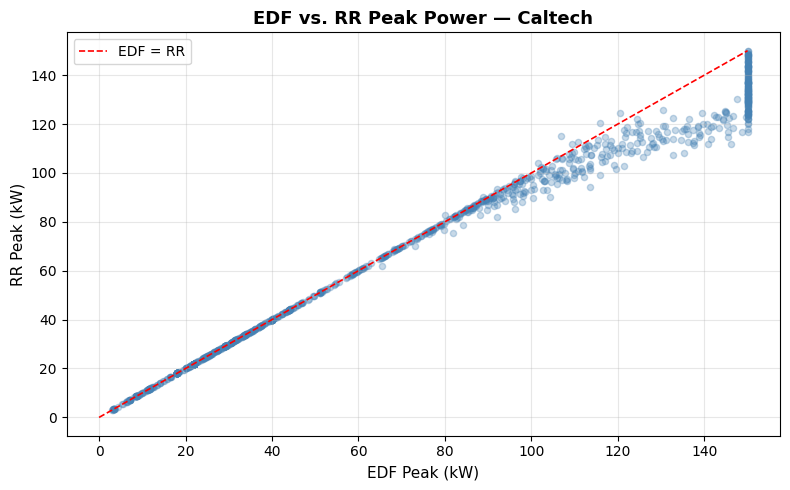

✅ Saved: figures/caltech_edf_vs_rr.png


In [59]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

os.makedirs('figures', exist_ok=True)

# ── 데이터 로드 ────────────────────────────────────────────
df_results = pd.read_csv('results/caltech_all_results.csv')
df_results['date'] = pd.to_datetime(df_results['date'])

# ── Figure 1: 날짜별 Peak 추이 ────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df_results['date'], df_results['uc_peak'],
        color='red', linewidth=1.0, linestyle='--', label='UC', alpha=0.8)
ax.plot(df_results['date'], df_results['edf_peak'],
        color='orange', linewidth=1.0, linestyle='-.', label='EDF', alpha=0.8)
ax.plot(df_results['date'], df_results['rr_peak'],
        color='green', linewidth=1.0, linestyle=':', label='RR', alpha=0.8)
ax.plot(df_results['date'], df_results['mip_peak'],
        color='steelblue', linewidth=1.2, label='MIP', alpha=0.9)

ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Peak Power (kW)', fontsize=11)
ax.set_title('Daily Peak Power — Caltech (Full Period)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('figures/caltech_peak_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: figures/caltech_peak_trend.png")


# ── Figure 2: Box Plot ────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))

data   = [df_results['mip_peak'], df_results['uc_peak'],
          df_results['edf_peak'], df_results['rr_peak']]
colors = ['steelblue', 'red', 'orange', 'green']
labels = ['MIP', 'UC', 'EDF', 'RR']

bp = ax.boxplot(data, labels=labels, patch_artist=True,
                medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_xlabel('Method', fontsize=11)
ax.set_ylabel('Peak Power (kW)', fontsize=11)
ax.set_title('Peak Power Distribution — Caltech',
             fontsize=13, fontweight='bold')
ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('figures/caltech_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: figures/caltech_boxplot.png")


# ── Figure 3: 차량 수 vs MIP 계산 시간 ───────────────────
fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(df_results['n_vehicles'], df_results['mip_time'],
           color='steelblue', alpha=0.4, edgecolors='white', s=30)

# 추세선
z = np.polyfit(df_results['n_vehicles'], df_results['mip_time'], 2)
p = np.poly1d(z)
x_line = np.linspace(df_results['n_vehicles'].min(),
                     df_results['n_vehicles'].max(), 100)
ax.plot(x_line, p(x_line), color='red', linewidth=1.5,
        linestyle='--', label='Trend')

ax.set_xlabel('Number of Vehicles', fontsize=11)
ax.set_ylabel('Computation Time (s)', fontsize=11)
ax.set_title('Vehicles vs. Computation Time — Caltech',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('figures/caltech_scalability.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: figures/caltech_scalability.png")


# ── Figure 4: Peak Reduction Rate 분포 ───────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

methods = [
    ('MIP', 'mip_peak', 'steelblue'),
    ('EDF', 'edf_peak', 'orange'),
    ('RR',  'rr_peak',  'green'),
]

for ax, (method, col, color) in zip(axes, methods):
    reduction = (
        (df_results['uc_peak'] - df_results[col]) /
        df_results['uc_peak'] * 100
    )
    ax.hist(reduction, bins=30, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(reduction.mean(), color='red', linestyle='--', linewidth=1.5,
               label=f'Mean={reduction.mean():.1f}%')
    ax.axvline(reduction.median(), color='black', linestyle=':', linewidth=1.5,
               label=f'Median={reduction.median():.1f}%')
    ax.set_xlabel('Peak Reduction Rate (%)', fontsize=10)
    ax.set_ylabel('Count', fontsize=10)
    ax.set_title(f'{method} vs. UC', fontsize=11, fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3, axis='y')

plt.suptitle('Peak Reduction Rate vs. UC — Caltech',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/caltech_reduction.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: figures/caltech_reduction.png")


# ── Figure 5: EDF vs RR 비교 (Caltech 특화) ──────────────
fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(df_results['edf_peak'], df_results['rr_peak'],
           color='steelblue', alpha=0.3, s=20)

# 대각선 (EDF = RR)
max_val = max(df_results['edf_peak'].max(), df_results['rr_peak'].max())
ax.plot([0, max_val], [0, max_val], color='red', linestyle='--',
        linewidth=1.2, label='EDF = RR')

ax.set_xlabel('EDF Peak (kW)', fontsize=11)
ax.set_ylabel('RR Peak (kW)', fontsize=11)
ax.set_title('EDF vs. RR Peak Power — Caltech',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('figures/caltech_edf_vs_rr.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: figures/caltech_edf_vs_rr.png")

In [60]:
import pandas as pd

df_results = pd.read_csv('results/caltech_all_results.csv')

# 차량 수별 대표 날짜 선정
print("=== Small (10~20대) ===")
small = df_results[(df_results['n_vehicles'] >= 10) & 
                   (df_results['n_vehicles'] <= 20)]
print(small.nsmallest(3, 'mip_time')[['date', 'n_vehicles', 'mip_peak', 'uc_peak']])

print("\n=== Medium (40~60대) ===")
medium = df_results[(df_results['n_vehicles'] >= 40) & 
                    (df_results['n_vehicles'] <= 60)]
print(medium.nsmallest(3, 'mip_time')[['date', 'n_vehicles', 'mip_peak', 'uc_peak']])

print("\n=== Large (80대 이상) ===")
large = df_results[df_results['n_vehicles'] >= 80]
print(large.nsmallest(3, 'mip_time')[['date', 'n_vehicles', 'mip_peak', 'uc_peak']])

=== Small (10~20대) ===
            date  n_vehicles  mip_peak  uc_peak
653   2020-02-08          10   14.8047   58.568
1004  2021-07-02          10    5.5528   24.236
981   2021-06-09          10    5.6573   22.000

=== Medium (40~60대) ===
           date  n_vehicles  mip_peak  uc_peak
649  2020-02-04          42   22.9292  145.464
670  2020-02-25          42   15.9545   96.090
546  2019-10-23          42   23.5506   97.636

=== Large (80대 이상) ===
           date  n_vehicles  mip_peak  uc_peak
169  2018-10-11          84   41.5362  176.949
103  2018-08-06          83   46.9111  144.714
112  2018-08-15          84   37.7396  146.544


### UC vs. EDF vs. RR vs. MIP

In [63]:
df_results = pd.read_csv('results/caltech_all_results.csv')

print(f"MIP Peak Mean: {df_results['mip_peak'].mean():.2f}")
print(f"MIP Peak Std:  {df_results['mip_peak'].std():.2f}")
print(f"MIP Peak Min:  {df_results['mip_peak'].min():.2f}")
print(f"MIP Peak Max:  {df_results['mip_peak'].max():.2f}")
print(f"MIP Time Mean: {df_results['mip_time'].mean():.4f}")
print(f"MIP Time Max:  {df_results['mip_time'].max():.4f}")
print(f"UC Peak Mean:  {df_results['uc_peak'].mean():.2f}")
print(f"UC Peak Max:   {df_results['uc_peak'].max():.2f}")
print(f"EDF Peak Mean: {df_results['edf_peak'].mean():.2f}")
print(f"RR Peak Mean:  {df_results['rr_peak'].mean():.2f}")

MIP Peak Mean: 16.80
MIP Peak Std:  12.71
MIP Peak Min:  0.18
MIP Peak Max:  56.59
MIP Time Mean: 0.0120
MIP Time Max:  0.1732
UC Peak Mean:  74.57
UC Peak Max:   327.52
EDF Peak Mean: 69.33
RR Peak Mean:  65.10


In [64]:
print(f"UC  Std: {df_results['uc_peak'].std():.2f}  Max: {df_results['uc_peak'].max():.2f}")
print(f"EDF Std: {df_results['edf_peak'].std():.2f}  Max: {df_results['edf_peak'].max():.2f}")
print(f"RR  Std: {df_results['rr_peak'].std():.2f}  Max: {df_results['rr_peak'].max():.2f}")
print(f"MIP Fulfillment: {(df_results['mip_satisfied'] == df_results['n_vehicles']).mean()*100:.1f}%")
print(f"UC  Fulfillment: {(df_results['uc_satisfied'] == df_results['n_vehicles']).mean()*100:.1f}%")
print(f"EDF Fulfillment: {(df_results['edf_satisfied'] == df_results['n_vehicles']).mean()*100:.1f}%")
print(f"RR  Fulfillment: {(df_results['rr_satisfied'] == df_results['n_vehicles']).mean()*100:.1f}%")

UC  Std: 60.33  Max: 327.52
EDF Std: 49.21  Max: 150.00
RR  Std: 43.62  Max: 150.00
MIP Fulfillment: 100.0%
UC  Fulfillment: 100.0%
EDF Fulfillment: 100.0%
RR  Fulfillment: 100.0%


In [65]:
print(f"UC  Std: {df_results['uc_peak'].std():.2f}  Max: {df_results['uc_peak'].max():.2f}")
print(f"EDF Std: {df_results['edf_peak'].std():.2f}  Max: {df_results['edf_peak'].max():.2f}")
print(f"RR  Std: {df_results['rr_peak'].std():.2f}  Max: {df_results['rr_peak'].max():.2f}")
print(f"MIP Fulfillment: {(df_results['mip_satisfied'] == df_results['n_vehicles']).mean()*100:.1f}%")
print(f"UC  Fulfillment: {(df_results['uc_satisfied'] == df_results['n_vehicles']).mean()*100:.1f}%")
print(f"EDF Fulfillment: {(df_results['edf_satisfied'] == df_results['n_vehicles']).mean()*100:.1f}%")
print(f"RR  Fulfillment: {(df_results['rr_satisfied'] == df_results['n_vehicles']).mean()*100:.1f}%")

UC  Std: 60.33  Max: 327.52
EDF Std: 49.21  Max: 150.00
RR  Std: 43.62  Max: 150.00
MIP Fulfillment: 100.0%
UC  Fulfillment: 100.0%
EDF Fulfillment: 100.0%
RR  Fulfillment: 100.0%


In [66]:
print(f"UC  Min: {df_results['uc_peak'].min():.2f}")
print(f"EDF Min: {df_results['edf_peak'].min():.2f}")
print(f"RR  Min: {df_results['rr_peak'].min():.2f}")

UC  Min: 3.00
EDF Min: 3.00
RR  Min: 3.00


## Sensitivity Analysis


=== Small (10 vehicles) (2019-07-21) ===
  ⚠️ 2019-07-21: 충전 불가 차량 1대 제거
  UC peak: 22.00 kW
  ⚠️ 2019-07-21: 충전 불가 차량 1대 제거
  C=   2 kW | Peak:   INFEASIBLE | Satisfied: 0/10 (0%) | 0.0020s
  ⚠️ 2019-07-21: 충전 불가 차량 1대 제거
  C=   4 kW | Peak:   INFEASIBLE | Satisfied: 0/10 (0%) | 0.0020s
  ⚠️ 2019-07-21: 충전 불가 차량 1대 제거
  C=   6 kW | Peak:      4.57 kW | Satisfied: 10/10 (100%) | 0.0040s
  ⚠️ 2019-07-21: 충전 불가 차량 1대 제거
  C=   8 kW | Peak:      4.57 kW | Satisfied: 10/10 (100%) | 0.0040s
  ⚠️ 2019-07-21: 충전 불가 차량 1대 제거
  C=  10 kW | Peak:      4.57 kW | Satisfied: 10/10 (100%) | 0.0040s
  ⚠️ 2019-07-21: 충전 불가 차량 1대 제거
  C=  12 kW | Peak:      4.57 kW | Satisfied: 10/10 (100%) | 0.0040s
  ⚠️ 2019-07-21: 충전 불가 차량 1대 제거
  C=  15 kW | Peak:      4.57 kW | Satisfied: 10/10 (100%) | 0.0040s
  ⚠️ 2019-07-21: 충전 불가 차량 1대 제거
  C=  18 kW | Peak:      4.57 kW | Satisfied: 10/10 (100%) | 0.0040s
  ⚠️ 2019-07-21: 충전 불가 차량 1대 제거
  C=  22 kW | Peak:      4.57 kW | Satisfied: 10/10 (100%) | 0.0050s

==

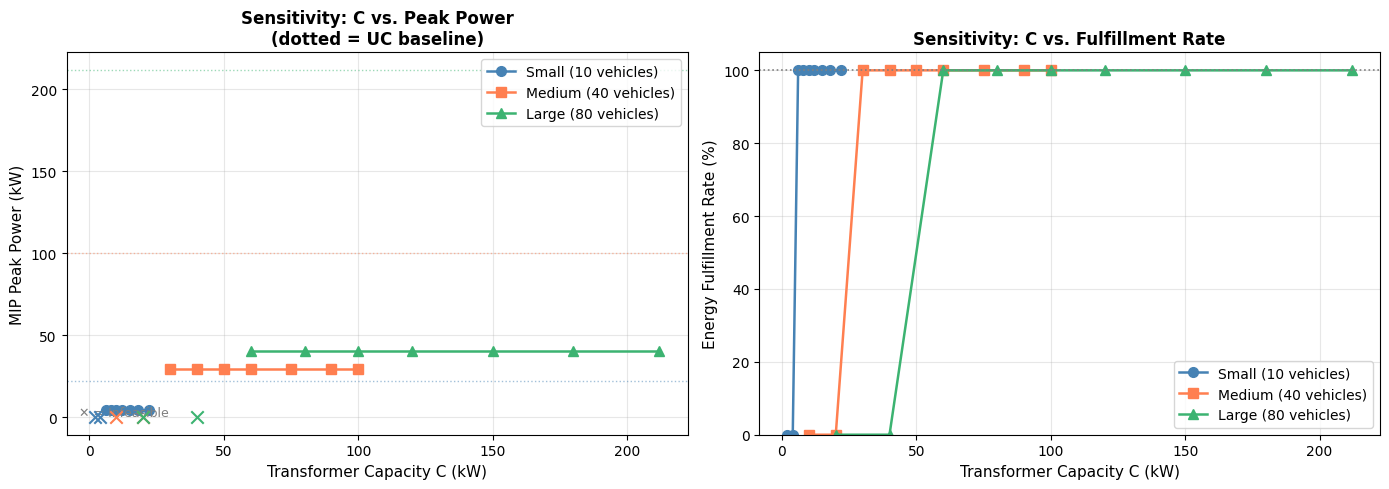


✅ Saved: figures/caltech_sensitivity.png


In [61]:
import pandas as pd
import numpy as np
import gurobipy as gp
from gurobipy import GRB
from datetime import date
import matplotlib.pyplot as plt
import time
import os

os.makedirs('figures', exist_ok=True)

# ── 0. 설정 ───────────────────────────────────────────────
target_dates = {
    'Small (10 vehicles)' : (date(2019, 7, 21),
                              [2, 4, 6, 8, 10, 12, 15, 18, 22]),
    'Medium (40 vehicles)': (date(2019, 8, 29),
                              [10, 20, 30, 40, 50, 60, 75, 90, 100]),
    'Large (80 vehicles)' : (date(2018, 10, 25),
                              [20, 40, 60, 80, 100, 120, 150, 180, 212]),
}

df_caltech = pd.read_csv('data/acn_caltech_clean.csv')
df_caltech['date'] = pd.to_datetime(df_caltech['date']).dt.date

# ── 1. 실험 ───────────────────────────────────────────────
sa_results = {label: [] for label in target_dates}

for label, (target, C_values) in target_dates.items():
    print(f"\n=== {label} ({target}) ===")

    inst_base = make_instance(df_caltech, target, site='caltech')
    if inst_base is None:
        continue
    n_veh = inst_base['n_vehicles']

    # UC peak 계산
    uc = run_uc(inst_base)
    uc_peak = uc['peak']
    print(f"  UC peak: {uc_peak:.2f} kW")

    for C_val in C_values:
        inst = make_instance(df_caltech, target, site='caltech')
        inst['C'] = C_val

        I, T    = inst['I'], inst['T']
        a, d    = inst['a'], inst['d']
        e       = inst['e']
        r_max   = inst['r_max']
        DELTA_T = inst['delta_t']

        mdl = gp.Model()
        mdl.setParam('OutputFlag', 0)
        mdl.setParam('TimeLimit', 60)

        r = mdl.addVars(I, T, lb=0, name='r')
        y = mdl.addVars(I, T, vtype=GRB.BINARY, name='y')
        Z = mdl.addVar(lb=0, name='Z')

        mdl.setObjective(Z, GRB.MINIMIZE)

        for i in I:
            mdl.addConstr(
                gp.quicksum(r[i, t] * DELTA_T
                            for t in range(a[i], d[i] + 1)) >= e[i]
            )
        for i in I:
            for t in T:
                mdl.addConstr(r[i, t] <= r_max[i] * y[i, t])
        for i in I:
            for t in T:
                if t < a[i] or t > d[i]:
                    mdl.addConstr(y[i, t] == 0)
        for t in T:
            mdl.addConstr(gp.quicksum(r[i, t] for i in I) <= Z)
        for t in T:
            mdl.addConstr(gp.quicksum(r[i, t] for i in I) <= C_val)

        start = time.time()
        mdl.optimize()
        elapsed = time.time() - start

        feasible = mdl.Status == GRB.OPTIMAL
        if feasible:
            mip_peak  = Z.X
            satisfied = sum(
                1 for i in I
                if sum(r[i, t].X * DELTA_T
                       for t in range(a[i], d[i] + 1)) >= e[i] - 0.01
            )
        else:
            mip_peak  = None
            satisfied = 0

        sa_results[label].append({
            'C'         : C_val,
            'mip_peak'  : mip_peak,
            'uc_peak'   : uc_peak,
            'satisfied' : satisfied,
            'n_vehicles': n_veh,
            'rate'      : satisfied / n_veh * 100,
            'time'      : round(elapsed, 4),
            'feasible'  : feasible,
        })

        status = f"{mip_peak:.2f} kW" if feasible else "INFEASIBLE"
        print(f"  C={C_val:>4} kW | Peak: {status:>12} | "
              f"Satisfied: {satisfied}/{n_veh} ({satisfied/n_veh*100:.0f}%) | "
              f"{elapsed:.4f}s")

# ── 2. 시각화 ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors  = ['steelblue', 'coral', 'mediumseagreen']
markers = ['o', 's', '^']

# Figure 1: C vs Peak Power
for (label, records), color, marker in zip(sa_results.items(), colors, markers):
    feasible_r   = [r for r in records if r['feasible']]
    infeasible_r = [r for r in records if not r['feasible']]

    C_f    = [r['C']        for r in feasible_r]
    peak_f = [r['mip_peak'] for r in feasible_r]
    uc_pk  = records[0]['uc_peak']

    axes[0].plot(C_f, peak_f, color=color, marker=marker,
                 linewidth=1.8, markersize=7, label=label)

    # UC peak 수평선
    axes[0].axhline(y=uc_pk, color=color, linestyle=':',
                    linewidth=1.0, alpha=0.5)

    # infeasible 표시
    if infeasible_r:
        C_inf = [r['C'] for r in infeasible_r]
        axes[0].scatter(C_inf, [0] * len(C_inf),
                        color=color, marker='x', s=80, zorder=5)

axes[0].set_xlabel('Transformer Capacity C (kW)', fontsize=11)
axes[0].set_ylabel('MIP Peak Power (kW)', fontsize=11)
axes[0].set_title('Sensitivity: C vs. Peak Power\n(dotted = UC baseline)',
                  fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3)
axes[0].text(0.02, 0.05, '✕ = Infeasible',
             transform=axes[0].transAxes, fontsize=9, color='gray')

# Figure 2: C vs Fulfillment Rate
for (label, records), color, marker in zip(sa_results.items(), colors, markers):
    C_vals = [r['C']    for r in records]
    rates  = [r['rate'] for r in records]
    axes[1].plot(C_vals, rates, color=color, marker=marker,
                 linewidth=1.8, markersize=7, label=label)

axes[1].axhline(y=100, color='gray', linestyle=':', linewidth=1.2)
axes[1].set_xlabel('Transformer Capacity C (kW)', fontsize=11)
axes[1].set_ylabel('Energy Fulfillment Rate (%)', fontsize=11)
axes[1].set_title('Sensitivity: C vs. Fulfillment Rate',
                  fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3)
axes[1].set_ylim(0, 105)

plt.tight_layout()
plt.savefig('figures/caltech_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ Saved: figures/caltech_sensitivity.png")

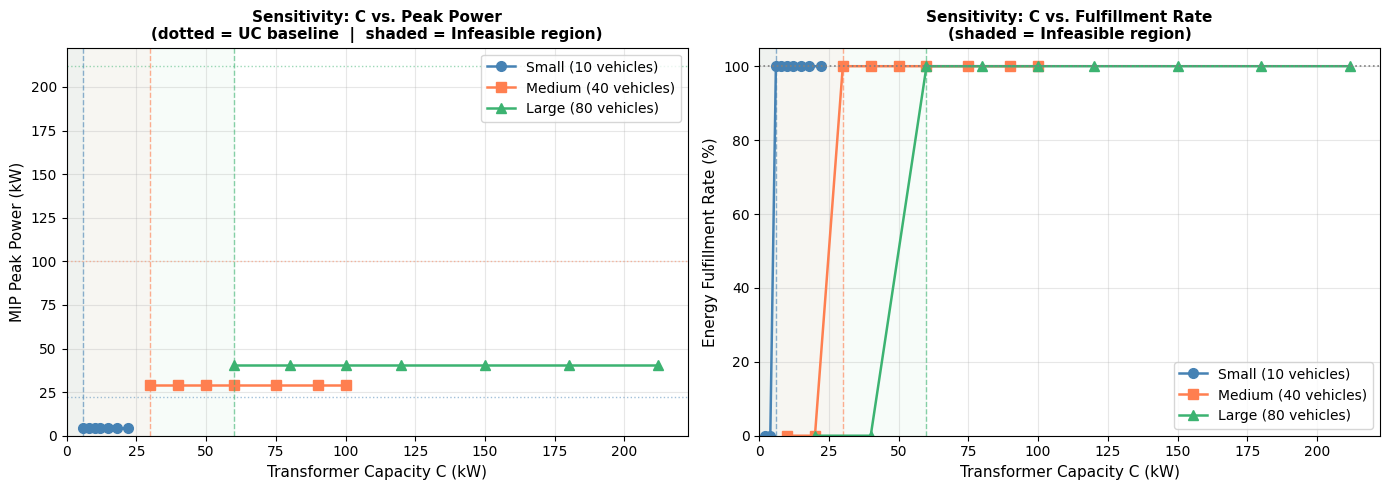

✅ Saved: figures/caltech_sensitivity.png


In [62]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors  = ['steelblue', 'coral', 'mediumseagreen']
markers = ['o', 's', '^']

# ── Figure 1: C vs Peak Power ─────────────────────────────
for (label, records), color, marker in zip(sa_results.items(), colors, markers):
    feasible_r   = [r for r in records if r['feasible']]
    infeasible_r = [r for r in records if not r['feasible']]

    C_f    = [r['C']        for r in feasible_r]
    peak_f = [r['mip_peak'] for r in feasible_r]
    uc_pk  = records[0]['uc_peak']

    # feasible 구간 선 + 점
    axes[0].plot(C_f, peak_f, color=color, marker=marker,
                 linewidth=1.8, markersize=7, label=label)

    # UC baseline 점선
    axes[0].axhline(y=uc_pk, color=color, linestyle=':',
                    linewidth=1.0, alpha=0.5)

    # INFEASIBLE 구간 → 음영 + 수직선
    if infeasible_r and feasible_r:
        min_feas_C = min(r['C'] for r in feasible_r)
        axes[0].axvspan(0, min_feas_C, alpha=0.04, color=color)
        axes[0].axvline(x=min_feas_C, color=color,
                        linestyle='--', linewidth=1.0, alpha=0.6)

axes[0].set_xlabel('Transformer Capacity C (kW)', fontsize=11)
axes[0].set_ylabel('MIP Peak Power (kW)', fontsize=11)
axes[0].set_title('Sensitivity: C vs. Peak Power\n(dotted = UC baseline  |  shaded = Infeasible region)',
                  fontsize=11, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3)
axes[0].set_xlim(left=0)
axes[0].set_ylim(bottom=0)

# ── Figure 2: C vs Fulfillment Rate ───────────────────────
for (label, records), color, marker in zip(sa_results.items(), colors, markers):
    C_vals = [r['C']    for r in records]
    rates  = [r['rate'] for r in records]

    axes[1].plot(C_vals, rates, color=color, marker=marker,
                 linewidth=1.8, markersize=7, label=label)

    # INFEASIBLE 구간 음영
    feasible_r = [r for r in records if r['feasible']]
    if feasible_r:
        min_feas_C = min(r['C'] for r in feasible_r)
        axes[1].axvspan(0, min_feas_C, alpha=0.04, color=color)
        axes[1].axvline(x=min_feas_C, color=color,
                        linestyle='--', linewidth=1.0, alpha=0.6)

axes[1].axhline(y=100, color='gray', linestyle=':', linewidth=1.2)
axes[1].set_xlabel('Transformer Capacity C (kW)', fontsize=11)
axes[1].set_ylabel('Energy Fulfillment Rate (%)', fontsize=11)
axes[1].set_title('Sensitivity: C vs. Fulfillment Rate\n(shaded = Infeasible region)',
                  fontsize=11, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3)
axes[1].set_ylim(0, 105)
axes[1].set_xlim(left=0)

plt.tight_layout()
plt.savefig('figures/caltech_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: figures/caltech_sensitivity.png")

### Extension Experment (C7)


=== Small (10 vehicles) (2019-07-21) ===
  ⚠️ 2019-07-21: 충전 불가 차량 1대 제거
  r_min=0.0 kW | Peak:      4.57 kW | Satisfied: 10/10 | Avg interruptions: 0.00 | 0.0070s
  r_min=0.5 kW | Peak:      4.57 kW | Satisfied: 10/10 | Avg interruptions: 0.90 | 0.0110s
  r_min=1.0 kW | Peak:      4.57 kW | Satisfied: 10/10 | Avg interruptions: 0.90 | 0.0110s
  r_min=1.4 kW | Peak:      4.57 kW | Satisfied: 10/10 | Avg interruptions: 0.90 | 0.0190s
  r_min=2.0 kW | Peak:      4.57 kW | Satisfied: 10/10 | Avg interruptions: 0.80 | 0.0160s
  r_min=3.0 kW | Peak:      4.91 kW | Satisfied: 10/10 | Avg interruptions: 0.60 | 0.0180s
  r_min=4.0 kW | Peak:      4.91 kW | Satisfied: 10/10 | Avg interruptions: 0.50 | 0.0150s

=== Medium (40 vehicles) (2019-08-29) ===
  r_min=0.0 kW | Peak:     29.31 kW | Satisfied: 40/40 | Avg interruptions: 0.00 | 0.0160s
  r_min=0.5 kW | Peak:     29.31 kW | Satisfied: 40/40 | Avg interruptions: 2.60 | 0.0590s
  r_min=1.0 kW | Peak:     29.31 kW | Satisfied: 40/40 | Avg int

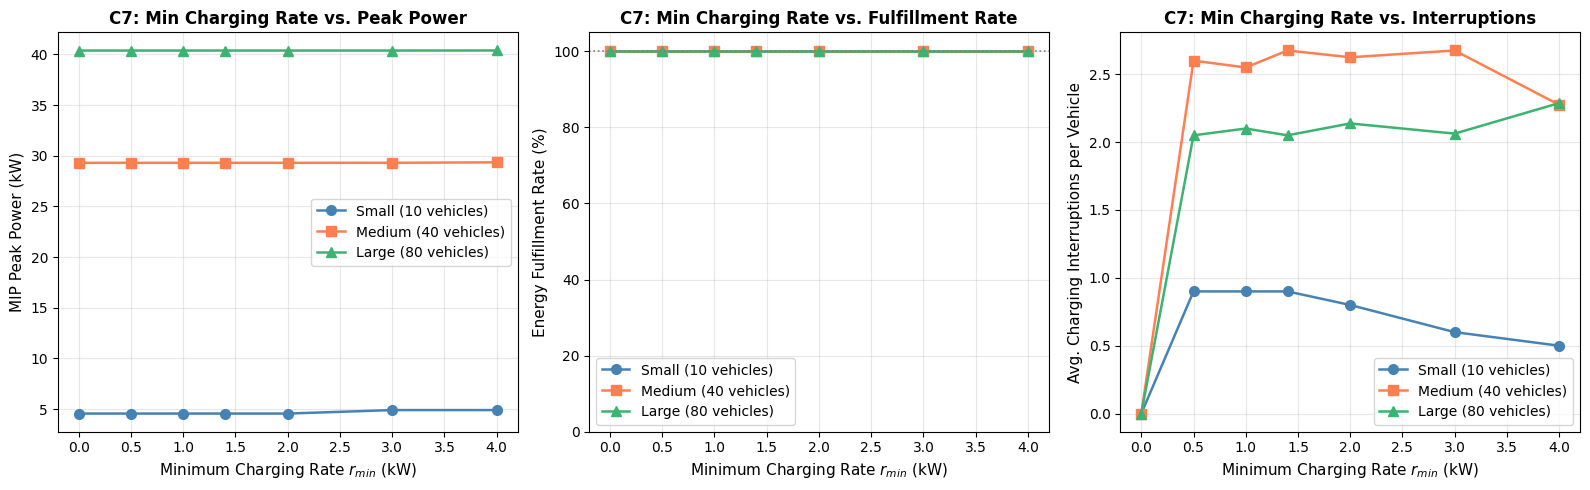

✅ Saved: figures/caltech_c7.png


In [67]:
import pandas as pd
import numpy as np
import gurobipy as gp
from gurobipy import GRB
from datetime import date
import matplotlib.pyplot as plt
import time
import os

os.makedirs('figures', exist_ok=True)

# ── 0. 설정 ───────────────────────────────────────────────
# 대표 날짜: Small / Medium / Large
target_dates = {
    'Small (10 vehicles)' : date(2019, 7, 21),
    'Medium (40 vehicles)': date(2019, 8, 29),
    'Large (80 vehicles)' : date(2018, 10, 25),
}

# 최소 충전율 후보값
r_min_values = [0.0, 0.5, 1.0, 1.4, 2.0, 3.0, 4.0]  # kW

df_caltech = pd.read_csv('data/acn_caltech_clean.csv')
df_caltech['date'] = pd.to_datetime(df_caltech['date']).dt.date

# ── 1. 실험 ───────────────────────────────────────────────
c7_results = {label: [] for label in target_dates}

for label, target in target_dates.items():
    print(f"\n=== {label} ({target}) ===")

    inst_base = make_instance(df_caltech, target, site='caltech')
    if inst_base is None:
        continue

    I, T    = inst_base['I'], inst_base['T']
    a, d    = inst_base['a'], inst_base['d']
    e       = inst_base['e']
    r_max   = inst_base['r_max']
    C       = inst_base['C']
    DELTA_T = inst_base['delta_t']
    n_veh   = inst_base['n_vehicles']

    for r_min in r_min_values:
        mdl = gp.Model()
        mdl.setParam('OutputFlag', 0)
        mdl.setParam('TimeLimit', 60)

        r = mdl.addVars(I, T, lb=0, name='r')
        y = mdl.addVars(I, T, vtype=GRB.BINARY, name='y')
        Z = mdl.addVar(lb=0, name='Z')

        mdl.setObjective(Z, GRB.MINIMIZE)

        # C1. 충전 완료
        for i in I:
            mdl.addConstr(
                gp.quicksum(r[i, t] * DELTA_T
                            for t in range(a[i], d[i] + 1)) >= e[i]
            )
        # C2. On/off 결합
        for i in I:
            for t in T:
                mdl.addConstr(r[i, t] <= r_max[i] * y[i, t])
        # C3. 가용 시간
        for i in I:
            for t in T:
                if t < a[i] or t > d[i]:
                    mdl.addConstr(y[i, t] == 0)
        # C4. 피크 정의
        for t in T:
            mdl.addConstr(gp.quicksum(r[i, t] for i in I) <= Z)
        # C5. 변압기 용량
        for t in T:
            mdl.addConstr(gp.quicksum(r[i, t] for i in I) <= C)
        # C7. 최소 충전율 (r_min > 0 일 때만 추가)
        if r_min > 0:
            for i in I:
                for t in T:
                    mdl.addConstr(r[i, t] >= r_min * y[i, t])

        start = time.time()
        mdl.optimize()
        elapsed = time.time() - start

        feasible = mdl.Status == GRB.OPTIMAL
        if feasible:
            mip_peak  = Z.X
            satisfied = sum(
                1 for i in I
                if sum(r[i, t].X * DELTA_T
                       for t in range(a[i], d[i] + 1)) >= e[i] - 0.01
            )
            # 충전 중단 횟수 계산
            interruptions = []
            for i in I:
                cnt = sum(
                    1 for t in range(a[i] + 1, d[i] + 1)
                    if y[i, t-1].X > 0.5 and y[i, t].X < 0.5
                )
                interruptions.append(cnt)
            avg_interruptions = np.mean(interruptions)
        else:
            mip_peak          = None
            satisfied         = 0
            avg_interruptions = None

        c7_results[label].append({
            'r_min'            : r_min,
            'mip_peak'         : mip_peak,
            'satisfied'        : satisfied,
            'rate'             : satisfied / n_veh * 100,
            'avg_interruptions': avg_interruptions,
            'time'             : round(elapsed, 4),
            'feasible'         : feasible,
            'n_vehicles'       : n_veh,
        })

        status = f"{mip_peak:.2f} kW" if feasible else "INFEASIBLE"
        intr   = f"{avg_interruptions:.2f}" if avg_interruptions is not None else "--"
        print(f"  r_min={r_min:.1f} kW | Peak: {status:>12} | "
              f"Satisfied: {satisfied}/{n_veh} | "
              f"Avg interruptions: {intr} | {elapsed:.4f}s")

# ── 2. 시각화 ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors  = ['steelblue', 'coral', 'mediumseagreen']
markers = ['o', 's', '^']

# Figure 1: r_min vs Peak Power
for (label, records), color, marker in zip(c7_results.items(), colors, markers):
    feasible_r = [r for r in records if r['feasible']]
    r_vals     = [r['r_min']    for r in feasible_r]
    peaks      = [r['mip_peak'] for r in feasible_r]
    axes[0].plot(r_vals, peaks, color=color, marker=marker,
                 linewidth=1.8, markersize=7, label=label)

    # infeasible 구간 음영
    infeasible_r = [r for r in records if not r['feasible']]
    if infeasible_r and feasible_r:
        max_inf = max(r['r_min'] for r in infeasible_r)
        axes[0].axvspan(max_inf, r_min_values[-1],
                        alpha=0.04, color=color)

axes[0].set_xlabel('Minimum Charging Rate $r_{min}$ (kW)', fontsize=11)
axes[0].set_ylabel('MIP Peak Power (kW)', fontsize=11)
axes[0].set_title('C7: Min Charging Rate vs. Peak Power',
                  fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3)

# Figure 2: r_min vs Fulfillment Rate
for (label, records), color, marker in zip(c7_results.items(), colors, markers):
    r_vals = [r['r_min'] for r in records]
    rates  = [r['rate']  for r in records]
    axes[1].plot(r_vals, rates, color=color, marker=marker,
                 linewidth=1.8, markersize=7, label=label)

axes[1].axhline(y=100, color='gray', linestyle=':', linewidth=1.2)
axes[1].set_xlabel('Minimum Charging Rate $r_{min}$ (kW)', fontsize=11)
axes[1].set_ylabel('Energy Fulfillment Rate (%)', fontsize=11)
axes[1].set_title('C7: Min Charging Rate vs. Fulfillment Rate',
                  fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3)
axes[1].set_ylim(0, 105)

# Figure 3: r_min vs Avg Interruptions
for (label, records), color, marker in zip(c7_results.items(), colors, markers):
    feasible_r = [r for r in records if r['feasible']]
    r_vals     = [r['r_min']            for r in feasible_r]
    intrs      = [r['avg_interruptions'] for r in feasible_r]
    axes[2].plot(r_vals, intrs, color=color, marker=marker,
                 linewidth=1.8, markersize=7, label=label)

axes[2].set_xlabel('Minimum Charging Rate $r_{min}$ (kW)', fontsize=11)
axes[2].set_ylabel('Avg. Charging Interruptions per Vehicle', fontsize=11)
axes[2].set_title('C7: Min Charging Rate vs. Interruptions',
                  fontsize=12, fontweight='bold')
axes[2].legend(fontsize=10)
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('figures/caltech_c7.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: figures/caltech_c7.png")

### Extension Experiment (C8)


=== Small (10 vehicles) (2019-07-21) ===
  ⚠️ 2019-07-21: 충전 불가 차량 1대 제거
  K=   0 | Peak:      4.57 kW | Satisfied: 10/10 | Avg interruptions: 0.00 | 0.0080s
  K=   1 | Peak:      4.57 kW | Satisfied: 10/10 | Avg interruptions: 0.00 | 0.0080s
  K=   2 | Peak:      4.57 kW | Satisfied: 10/10 | Avg interruptions: 0.00 | 0.0080s
  K=   3 | Peak:      4.57 kW | Satisfied: 10/10 | Avg interruptions: 0.00 | 0.0093s
  K=   5 | Peak:      4.57 kW | Satisfied: 10/10 | Avg interruptions: 0.00 | 0.0090s
  K=  10 | Peak:      4.57 kW | Satisfied: 10/10 | Avg interruptions: 0.00 | 0.0090s
  K=   ∞ | Peak:      4.57 kW | Satisfied: 10/10 | Avg interruptions: 0.00 | 0.0070s

=== Medium (40 vehicles) (2019-08-29) ===
  K=   0 | Peak:     29.31 kW | Satisfied: 40/40 | Avg interruptions: 0.00 | 0.0250s
  K=   1 | Peak:     29.31 kW | Satisfied: 40/40 | Avg interruptions: 0.00 | 0.0280s
  K=   2 | Peak:     29.31 kW | Satisfied: 40/40 | Avg interruptions: 0.00 | 0.0260s
  K=   3 | Peak:     29.31 kW | S

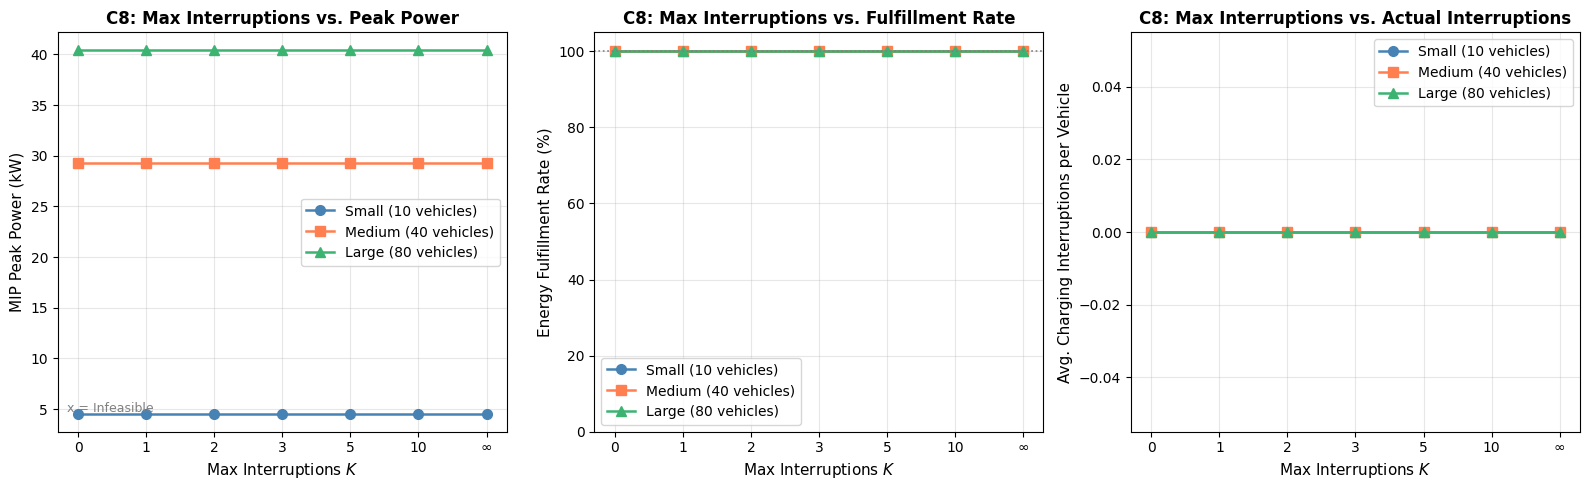

✅ Saved: figures/caltech_c8.png


In [68]:
# ── 0. 설정 ───────────────────────────────────────────────
# K = 최대 충전 중단 횟수
K_values = [0, 1, 2, 3, 5, 10, 999]  # 999 = 사실상 무제한

target_dates = {
    'Small (10 vehicles)' : date(2019, 7, 21),
    'Medium (40 vehicles)': date(2019, 8, 29),
    'Large (80 vehicles)' : date(2018, 10, 25),
}

df_caltech = pd.read_csv('data/acn_caltech_clean.csv')
df_caltech['date'] = pd.to_datetime(df_caltech['date']).dt.date

# ── 1. 실험 ───────────────────────────────────────────────
c8_results = {label: [] for label in target_dates}

for label, target in target_dates.items():
    print(f"\n=== {label} ({target}) ===")

    inst_base = make_instance(df_caltech, target, site='caltech')
    if inst_base is None:
        continue

    I, T    = inst_base['I'], inst_base['T']
    a, d    = inst_base['a'], inst_base['d']
    e       = inst_base['e']
    r_max   = inst_base['r_max']
    C       = inst_base['C']
    DELTA_T = inst_base['delta_t']
    n_veh   = inst_base['n_vehicles']

    for K in K_values:
        mdl = gp.Model()
        mdl.setParam('OutputFlag', 0)
        mdl.setParam('TimeLimit', 60)

        r = mdl.addVars(I, T, lb=0, name='r')
        y = mdl.addVars(I, T, vtype=GRB.BINARY, name='y')
        Z = mdl.addVar(lb=0, name='Z')

        mdl.setObjective(Z, GRB.MINIMIZE)

        # C1 ~ C5 기본 제약
        for i in I:
            mdl.addConstr(
                gp.quicksum(r[i, t] * DELTA_T
                            for t in range(a[i], d[i] + 1)) >= e[i]
            )
        for i in I:
            for t in T:
                mdl.addConstr(r[i, t] <= r_max[i] * y[i, t])
        for i in I:
            for t in T:
                if t < a[i] or t > d[i]:
                    mdl.addConstr(y[i, t] == 0)
        for t in T:
            mdl.addConstr(gp.quicksum(r[i, t] for i in I) <= Z)
        for t in T:
            mdl.addConstr(gp.quicksum(r[i, t] for i in I) <= C)

        # C8. 충전 중단 횟수 제약 (K < 999 일 때만)
        if K < 999:
            # 선형화: zᵢₜ ≥ yᵢ,ₜ₋₁ - yᵢₜ
            z_int = mdl.addVars(I, T, lb=0, name='z')
            for i in I:
                for t in range(a[i] + 1, d[i] + 1):
                    mdl.addConstr(z_int[i, t] >= y[i, t-1] - y[i, t])
                mdl.addConstr(
                    gp.quicksum(z_int[i, t]
                                for t in range(a[i] + 1, d[i] + 1)) <= K
                )

        start = time.time()
        mdl.optimize()
        elapsed = time.time() - start

        feasible = mdl.Status == GRB.OPTIMAL
        if feasible:
            mip_peak  = Z.X
            satisfied = sum(
                1 for i in I
                if sum(r[i, t].X * DELTA_T
                       for t in range(a[i], d[i] + 1)) >= e[i] - 0.01
            )
            # 실제 충전 중단 횟수 계산
            interruptions = []
            for i in I:
                cnt = sum(
                    1 for t in range(a[i] + 1, d[i] + 1)
                    if y[i, t-1].X > 0.5 and y[i, t].X < 0.5
                )
                interruptions.append(cnt)
            avg_interruptions = np.mean(interruptions)
        else:
            mip_peak          = None
            satisfied         = 0
            avg_interruptions = None

        c8_results[label].append({
            'K'                : K,
            'mip_peak'         : mip_peak,
            'satisfied'        : satisfied,
            'rate'             : satisfied / n_veh * 100,
            'avg_interruptions': avg_interruptions,
            'time'             : round(elapsed, 4),
            'feasible'         : feasible,
            'n_vehicles'       : n_veh,
        })

        K_label = str(K) if K < 999 else '∞'
        status  = f"{mip_peak:.2f} kW" if feasible else "INFEASIBLE"
        intr    = f"{avg_interruptions:.2f}" if avg_interruptions is not None else "--"
        print(f"  K={K_label:>4} | Peak: {status:>12} | "
              f"Satisfied: {satisfied}/{n_veh} | "
              f"Avg interruptions: {intr} | {elapsed:.4f}s")

# ── 2. 시각화 ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors  = ['steelblue', 'coral', 'mediumseagreen']
markers = ['o', 's', '^']

x_labels = [str(K) if K < 999 else '∞' for K in K_values]
x_pos    = list(range(len(K_values)))

# Figure 1: K vs Peak Power
for (label, records), color, marker in zip(c8_results.items(), colors, markers):
    feasible_r = [r for r in records if r['feasible']]
    x_vals     = [x_pos[K_values.index(r['K'])] for r in feasible_r]
    peaks      = [r['mip_peak'] for r in feasible_r]
    axes[0].plot(x_vals, peaks, color=color, marker=marker,
                 linewidth=1.8, markersize=7, label=label)

    # infeasible 표시
    infeasible_r = [r for r in records if not r['feasible']]
    if infeasible_r:
        x_inf = [x_pos[K_values.index(r['K'])] for r in infeasible_r]
        axes[0].scatter(x_inf, [0] * len(x_inf),
                        color=color, marker='x', s=80, zorder=5)

axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(x_labels)
axes[0].set_xlabel('Max Interruptions $K$', fontsize=11)
axes[0].set_ylabel('MIP Peak Power (kW)', fontsize=11)
axes[0].set_title('C8: Max Interruptions vs. Peak Power',
                  fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3)
axes[0].text(0.02, 0.05, 'x = Infeasible',
             transform=axes[0].transAxes, fontsize=9, color='gray')

# Figure 2: K vs Fulfillment Rate
for (label, records), color, marker in zip(c8_results.items(), colors, markers):
    x_vals = x_pos
    rates  = [r['rate'] for r in records]
    axes[1].plot(x_vals, rates, color=color, marker=marker,
                 linewidth=1.8, markersize=7, label=label)

axes[1].axhline(y=100, color='gray', linestyle=':', linewidth=1.2)
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(x_labels)
axes[1].set_xlabel('Max Interruptions $K$', fontsize=11)
axes[1].set_ylabel('Energy Fulfillment Rate (%)', fontsize=11)
axes[1].set_title('C8: Max Interruptions vs. Fulfillment Rate',
                  fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3)
axes[1].set_ylim(0, 105)

# Figure 3: K vs Avg Interruptions
for (label, records), color, marker in zip(c8_results.items(), colors, markers):
    feasible_r = [r for r in records if r['feasible']]
    x_vals     = [x_pos[K_values.index(r['K'])] for r in feasible_r]
    intrs      = [r['avg_interruptions'] for r in feasible_r]
    axes[2].plot(x_vals, intrs, color=color, marker=marker,
                 linewidth=1.8, markersize=7, label=label)

axes[2].set_xticks(x_pos)
axes[2].set_xticklabels(x_labels)
axes[2].set_xlabel('Max Interruptions $K$', fontsize=11)
axes[2].set_ylabel('Avg. Charging Interruptions per Vehicle', fontsize=11)
axes[2].set_title('C8: Max Interruptions vs. Actual Interruptions',
                  fontsize=12, fontweight='bold')
axes[2].legend(fontsize=10)
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('figures/caltech_c8.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: figures/caltech_c8.png")

### Extension Experiment (TOU)


=== Small (10 vehicles) (2019-07-21) ===
  ⚠️ 2019-07-21: 충전 불가 차량 1대 제거
  μ=  0 $/kW | Peak:     25.00 kW | TOU Cost:      $4.94 | Satisfied: 10/10 | 0.0050s
  μ=  5 $/kW | Peak:      4.57 kW | TOU Cost:      $5.52 | Satisfied: 10/10 | 0.0080s
  μ= 10 $/kW | Peak:      4.57 kW | TOU Cost:      $5.52 | Satisfied: 10/10 | 0.0070s
  μ= 15 $/kW | Peak:      4.57 kW | TOU Cost:      $5.52 | Satisfied: 10/10 | 0.0075s
  μ= 20 $/kW | Peak:      4.57 kW | TOU Cost:      $5.52 | Satisfied: 10/10 | 0.0070s

=== Medium (40 vehicles) (2019-08-29) ===
  μ=  0 $/kW | Peak:    109.00 kW | TOU Cost:     $46.11 | Satisfied: 40/40 | 0.0160s
  μ=  5 $/kW | Peak:     29.31 kW | TOU Cost:     $73.64 | Satisfied: 40/40 | 0.0170s
  μ= 10 $/kW | Peak:     29.31 kW | TOU Cost:     $73.64 | Satisfied: 40/40 | 0.0170s
  μ= 15 $/kW | Peak:     29.31 kW | TOU Cost:     $73.64 | Satisfied: 40/40 | 0.0170s
  μ= 20 $/kW | Peak:     29.31 kW | TOU Cost:     $73.64 | Satisfied: 40/40 | 0.0190s

=== Large (80 vehicles

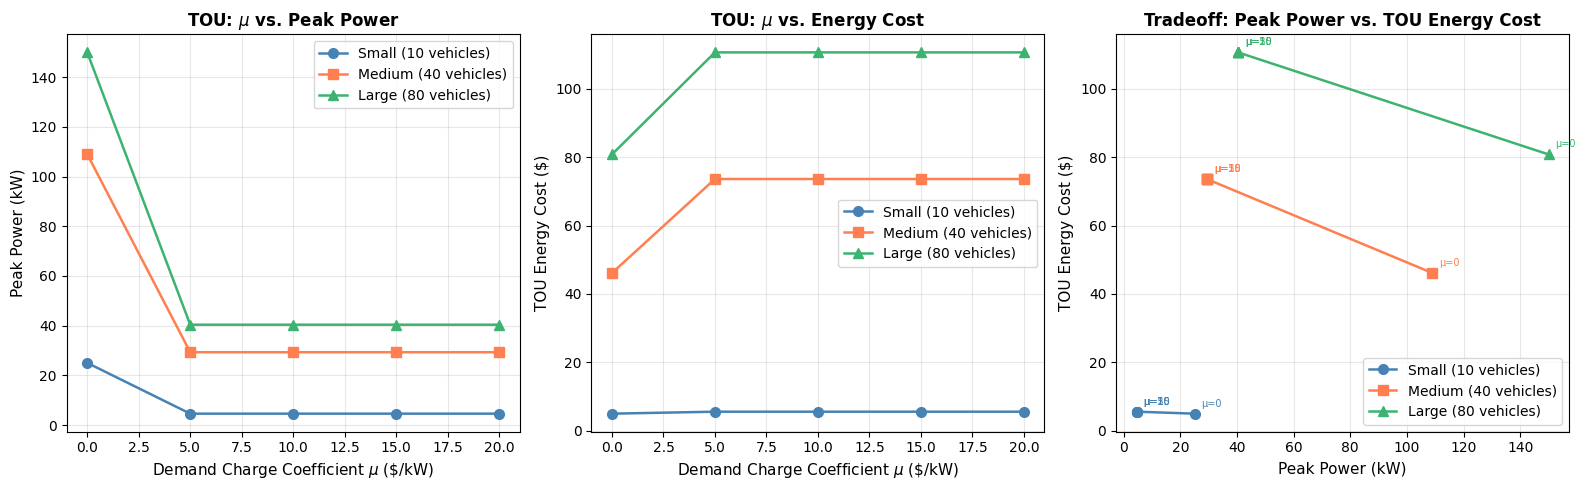

✅ Saved: figures/caltech_tou.png


In [69]:
import pandas as pd
import numpy as np
import gurobipy as gp
from gurobipy import GRB
from datetime import date
import matplotlib.pyplot as plt
import json, os, time

os.makedirs('figures', exist_ok=True)

# ── 0. TOU 요금표 로드 ────────────────────────────────────
tariff_path = r'c:\Users\geo48\anaconda3\envs\DO\Lib\site-packages\acnportal\signals\tariffs\tariff_schedules\sce_tou_ev_8_june_2019.json'

def get_lambda_t(target_date, T, delta_t=0.25):
    with open(tariff_path, 'r') as f:
        tariff = json.load(f)

    month      = target_date.month
    is_summer  = 6 <= month <= 9
    is_weekday = target_date.weekday() < 5

    schedule = None
    for s in tariff['schedule']:
        sid = s['id']
        dow = s['dow_mask']
        if is_summer:
            if 'Summer' not in sid:
                continue
            if is_weekday and dow != 'WEEKDAYS':
                continue
            if not is_weekday and dow != 'WEEKENDS':
                continue
        else:
            if sid != 'Winter':
                continue
        schedule = s
        break

    if schedule is None:
        return {t: 0.12 for t in T}

    times   = schedule['times']
    tariffs = schedule['tariffs']

    lambda_t = {}
    for t in T:
        hour = t * delta_t
        rate = tariffs[-1]
        for idx in range(len(times)):
            if idx + 1 < len(times):
                if times[idx] <= hour < times[idx + 1]:
                    rate = tariffs[idx]
                    break
            else:
                if hour >= times[idx]:
                    rate = tariffs[idx]
        lambda_t[t] = rate
    return lambda_t

# ── 1. 설정 ───────────────────────────────────────────────
target_dates = {
    'Small (10 vehicles)' : date(2019, 7, 21),
    'Medium (40 vehicles)': date(2019, 8, 29),
    'Large (80 vehicles)' : date(2018, 10, 25),
}

mu_values = [0, 5, 10, 15, 20]  # $/kW

df_caltech = pd.read_csv('data/acn_caltech_clean.csv')
df_caltech['date'] = pd.to_datetime(df_caltech['date']).dt.date

# ── 2. 실험 ───────────────────────────────────────────────
tou_results = {label: [] for label in target_dates}

for label, target in target_dates.items():
    print(f"\n=== {label} ({target}) ===")

    inst = make_instance(df_caltech, target, site='caltech')
    if inst is None:
        continue

    I, T    = inst['I'], inst['T']
    a, d    = inst['a'], inst['d']
    e       = inst['e']
    r_max   = inst['r_max']
    C       = inst['C']
    DELTA_T = inst['delta_t']
    n_veh   = inst['n_vehicles']

    # TOU 요금표
    lambda_t = get_lambda_t(target, T)

    # Base MIP (min Z) 결과 저장용
    base_peak = None

    for mu in mu_values:
        mdl = gp.Model()
        mdl.setParam('OutputFlag', 0)
        mdl.setParam('TimeLimit', 60)

        r = mdl.addVars(I, T, lb=0, name='r')
        y = mdl.addVars(I, T, vtype=GRB.BINARY, name='y')
        Z = mdl.addVar(lb=0, name='Z')

        # 목적함수: TOU 에너지 비용 + 수요 요금
        tou_cost = gp.quicksum(
            lambda_t[t] * r[i, t] * DELTA_T
            for i in I for t in T
        )
        demand_charge = mu * Z
        mdl.setObjective(tou_cost + demand_charge, GRB.MINIMIZE)

        # C1 ~ C5
        for i in I:
            mdl.addConstr(
                gp.quicksum(r[i, t] * DELTA_T
                            for t in range(a[i], d[i] + 1)) >= e[i]
            )
        for i in I:
            for t in T:
                mdl.addConstr(r[i, t] <= r_max[i] * y[i, t])
        for i in I:
            for t in T:
                if t < a[i] or t > d[i]:
                    mdl.addConstr(y[i, t] == 0)
        for t in T:
            mdl.addConstr(gp.quicksum(r[i, t] for i in I) <= Z)
        for t in T:
            mdl.addConstr(gp.quicksum(r[i, t] for i in I) <= C)

        start = time.time()
        mdl.optimize()
        elapsed = time.time() - start

        feasible = mdl.Status == GRB.OPTIMAL
        if feasible:
            mip_peak = Z.X

            # TOU 에너지 비용 계산
            tou_energy_cost = sum(
                lambda_t[t] * r[i, t].X * DELTA_T
                for i in I for t in T
            )
            # 총 비용
            total_cost = tou_energy_cost + mu * mip_peak

            satisfied = sum(
                1 for i in I
                if sum(r[i, t].X * DELTA_T
                       for t in range(a[i], d[i] + 1)) >= e[i] - 0.01
            )

            if mu == 0:
                base_peak = mip_peak
        else:
            mip_peak        = None
            tou_energy_cost = None
            total_cost      = None
            satisfied       = 0

        tou_results[label].append({
            'mu'             : mu,
            'mip_peak'       : mip_peak,
            'tou_energy_cost': tou_energy_cost,
            'total_cost'     : total_cost,
            'satisfied'      : satisfied,
            'rate'           : satisfied / n_veh * 100,
            'time'           : round(elapsed, 4),
            'feasible'       : feasible,
            'n_vehicles'     : n_veh,
        })

        status = f"{mip_peak:.2f} kW" if feasible else "INFEASIBLE"
        cost   = f"${tou_energy_cost:.2f}" if tou_energy_cost else "--"
        print(f"  μ={mu:>3} $/kW | Peak: {status:>12} | "
              f"TOU Cost: {cost:>10} | "
              f"Satisfied: {satisfied}/{n_veh} | {elapsed:.4f}s")

# ── 3. 시각화 ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors  = ['steelblue', 'coral', 'mediumseagreen']
markers = ['o', 's', '^']

# Figure 1: μ vs Peak Power
for (label, records), color, marker in zip(tou_results.items(), colors, markers):
    feasible_r = [r for r in records if r['feasible']]
    mu_vals    = [r['mu']       for r in feasible_r]
    peaks      = [r['mip_peak'] for r in feasible_r]
    axes[0].plot(mu_vals, peaks, color=color, marker=marker,
                 linewidth=1.8, markersize=7, label=label)

axes[0].set_xlabel('Demand Charge Coefficient $\\mu$ (\\$/kW)', fontsize=11)
axes[0].set_ylabel('Peak Power (kW)', fontsize=11)
axes[0].set_title('TOU: $\\mu$ vs. Peak Power',
                  fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3)

# Figure 2: μ vs TOU Energy Cost
for (label, records), color, marker in zip(tou_results.items(), colors, markers):
    feasible_r = [r for r in records if r['feasible']]
    mu_vals    = [r['mu']             for r in feasible_r]
    costs      = [r['tou_energy_cost'] for r in feasible_r]
    axes[1].plot(mu_vals, costs, color=color, marker=marker,
                 linewidth=1.8, markersize=7, label=label)

axes[1].set_xlabel('Demand Charge Coefficient $\\mu$ (\\$/kW)', fontsize=11)
axes[1].set_ylabel('TOU Energy Cost ($)', fontsize=11)
axes[1].set_title('TOU: $\\mu$ vs. Energy Cost',
                  fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3)

# Figure 3: Peak vs TOU Energy Cost (tradeoff)
for (label, records), color, marker in zip(tou_results.items(), colors, markers):
    feasible_r = [r for r in records if r['feasible']]
    peaks      = [r['mip_peak']        for r in feasible_r]
    costs      = [r['tou_energy_cost'] for r in feasible_r]
    axes[2].plot(peaks, costs, color=color, marker=marker,
                 linewidth=1.8, markersize=7, label=label)

    # μ 값 레이블 표시
    for r in feasible_r:
        axes[2].annotate(
            f"μ={r['mu']}",
            (r['mip_peak'], r['tou_energy_cost']),
            textcoords='offset points',
            xytext=(5, 5), fontsize=7, color=color
        )

axes[2].set_xlabel('Peak Power (kW)', fontsize=11)
axes[2].set_ylabel('TOU Energy Cost ($)', fontsize=11)
axes[2].set_title('Tradeoff: Peak Power vs. TOU Energy Cost',
                  fontsize=12, fontweight='bold')
axes[2].legend(fontsize=10)
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('figures/caltech_tou.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: figures/caltech_tou.png")